# Import libraries

In [1]:
import pandas as pd
import numpy as np
import torch
from typing import List, Tuple, Union
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from scipy.stats import boxcox
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from plotly import express as px
import plotly.figure_factory as ff
from sklearn.preprocessing import LabelEncoder
import shap
import lightgbm as lgb
from lightgbm import LGBMClassifier
import optuna
import warnings
import random
warnings.simplefilter('ignore')

In [2]:
class Plots:
    def __init__(self):
        pass

    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray) and not torch.is_tensor(data):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        data = np.array(data)
        if(data.ndim == 2):
            data = data.squeeze()
        return data
    
    def check_2d_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray) and not torch.is_tensor(data):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array or torch tensor.')
        return np.array(data)
    
    def pie_and_bar_plot(self, data, name=""):
        data = self.check_data(data=data)
        data = list(data)
        rows = 1
        columns = 2
        labels, frequency = np.unique(data, return_counts=True)
        colors = px.colors.qualitative.Plotly
        fig = make_subplots(rows=rows, cols=columns, specs=[[{"type": "pie"}, {"type": "bar"}] for i in range(0, rows)])
        fig.add_trace(go.Pie(values=frequency, labels=labels, showlegend=True, textinfo='value+percent', hole=0.3, marker=dict(line=dict(color='black', width=2), colors=colors)), row=1, col=1)
        fig.add_trace(go.Bar(x=labels, y=frequency, marker=dict(line=dict(color='black', width=1), color=colors), showlegend=False), row=1, col=2)
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>Pie chart and bar chart {name.title()}<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")

    def box_and_hist_plot(self, train, test, name="", bin_size=1):
        train = self.check_data(data=train)
        test = self.check_data(data=test)
        rows = 1
        columns = 2
        fig = make_subplots(rows=rows, cols=columns, specs=[[{"type": "box"}, {"type": "histogram"}] for i in range(0, rows)])
        fig.add_trace(go.Box(y=train, showlegend=True, name="Train", marker=dict(color='blue')), row=1, col=1)
        fig.add_trace(go.Box(y=test, showlegend=True, name="Test", marker=dict(color='red')), row=1, col=1)
        fig.add_trace(go.Histogram(x=train, showlegend=False, name="Train", marker=dict(color='blue')), row=1, col=2)
        fig.add_trace(go.Histogram(x=test, showlegend=False, name="Test", marker=dict(color='red'), xbins=dict(size=bin_size)), row=1, col=2)
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>Box plot and histogram {name.title()}<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def barplot_and_violine_plot(self, data, hue, name=""):
        data = self.check_data(data=data)
        hue = self.check_data(data=hue)
        fig = make_subplots(rows=1, cols=2, specs=[[{"type": "bar"}, {"type": "violin"}]])
        colors = px.colors.qualitative.Plotly
        for color_idx, category in enumerate(np.unique(hue)):
            indices = list(np.where(hue==category)[0])
            grouped_data = list(data[indices])
            labels, frequency = [category], [np.mean(grouped_data)]
            fig.add_trace(go.Bar(y=labels, x=frequency, name=str(category), marker=dict(line=dict(color='black', width=1), color=colors[color_idx]), showlegend=True, orientation="h"), row=1, col=1)
            fig.add_annotation(x=frequency[0]/2, y=category, text=str(np.round(frequency[0], 3)), showarrow=False)
            fig.add_trace(go.Violin(x=grouped_data, name=str(category), showlegend=False, line_color=colors[color_idx]), row=1, col=2)
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>Bar plot and violin plot {name.title()}<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def correlation_plot(self, data, features_names):
        data = self.check_data(data=data)
        data = pd.DataFrame(data, columns=features_names)
        corr = np.round(data[data.columns.tolist()].corr(method='spearman'), 3)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        data_mask = corr.mask(mask)
        fig = ff.create_annotated_heatmap(z=data_mask.to_numpy(), x=data_mask.columns.tolist(), y=data_mask.columns.tolist(), colorscale=px.colors.diverging.RdBu,hoverinfo="none", showscale=True, ygap=1, xgap=1)
        fig.update_xaxes(side="bottom")
        fig.update_layout(width=1200, height=800,xaxis_showgrid=False,yaxis_showgrid=False,xaxis_zeroline=False,yaxis_zeroline=False,yaxis_autorange='reversed',template='plotly_white',font=dict(family="Times New Roman",size=12,color="Black"))
        for i in range(len(fig.layout.annotations)):
            if fig.layout.annotations[i].text == 'nan':
                fig.layout.annotations[i].text = ""
        fig.show("png")
    
    def multilabel_conf_matrix(self, y_true, y_pred, labels, normalize=False):
        if(normalize==True):
            CM = confusion_matrix(y_true, y_pred, normalize='true')
        else:
            CM = confusion_matrix(y_true, y_pred, normalize=None)
        z = []
        for i in range(len(labels)):
            z.append([])
            for j in range(len(labels)):
                z[i].append(np.round(CM[i][j], 3))
        z_text = [[str(y) for y in x] for x in z]
        x = [i for i in labels]
        y =  [i for i in labels]
        fig = ff.create_annotated_heatmap(z, x=x, y=y, annotation_text=z_text, colorscale='blues')
        fig.update_layout(template="simple_white", width=1200, height=1200, showlegend=False, font=dict(family="Times New Roman",size=16,color="Black"), title_text="<b>Normalized confusion matrix<br>Balanced accuracy score: {}<b>".format(np.round(balanced_accuracy_score(y_true, y_pred), 4)), title_x=0.5, title_y=0.97)
        fig.add_annotation(dict(font=dict(family="Times New Roman",size=20,color="Black"),x=-0.15,y=0.5,showarrow=False,text="Actual",textangle=-90,xref="paper",yref="paper"))
        fig.add_annotation(dict(font=dict(family="Times New Roman",size=20,color="Black"),x=0.5,y=1.1,showarrow=False,text="Predictions",xref="paper",yref="paper"))
        fig['data'][0]['showscale'] = True
        fig.show("png")
    
    def plot_feature_importances(self, results, importance_type):
        sorted = results.sort_values(by=f'{importance_type}_mean', ascending=False)
        colors = px.colors.qualitative.Plotly
        fig = go.Figure()
        fig.add_trace(go.Bar(x=sorted['feature'], y=sorted[f'{importance_type}_mean'], marker=dict(color=sorted[f'{importance_type}_mean'], colorscale=colors, line=dict(color='black', width=1)), error_y=dict(type='data', array=sorted[f'{importance_type}_std'], visible=True)))
        fig.update_layout(template="simple_white", width=1600, height=800, title_text=f"<b>Feature importance {importance_type.title()}<b>", title_x=0.5, yaxis_title="Feature importance", xaxis=dict(title='Features', showticklabels=True, type="category"), font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def simple_feature_importance(self, feature_importance, importance_type):
        sorted = feature_importance.sort_values(by=importance_type, ascending=False)
        colors = px.colors.qualitative.Plotly
        fig = go.Figure()
        fig.add_trace(go.Bar(x=sorted.index, y=sorted[importance_type], marker=dict(color=sorted[importance_type], colorscale=colors, line=dict(color='black', width=1))))
        fig.update_layout(template="simple_white", width=1600, height=800, title_text="<b>Feature importance<b>", title_x=0.5, yaxis_title="Feature importance", xaxis=dict(title='Features', showticklabels=True, type="category"), font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
plots = Plots()

# Problem understanding

$\text{Use various factors to predict obesity risk in individuals, which is related to cardiovascular disease.}$

# Data loading

In [3]:
train_data = pd.read_csv("input/train.csv")
target_variable = "NObeyesdad"
train_data.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
test_data = pd.read_csv("input/test.csv")
test_data["CALC"] = test_data["CALC"].replace("Always", "Frequently")
test_data.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,20758,Male,26.899886,1.848294,120.644178,yes,yes,2.938616,3.000000,Sometimes,no,2.825629,no,0.855400,0.000000,Sometimes,Public_Transportation
1,20759,Female,21.000000,1.600000,66.000000,yes,yes,2.000000,1.000000,Sometimes,no,3.000000,no,1.000000,0.000000,Sometimes,Public_Transportation
2,20760,Female,26.000000,1.643355,111.600553,yes,yes,3.000000,3.000000,Sometimes,no,2.621877,no,0.000000,0.250502,Sometimes,Public_Transportation
3,20761,Male,20.979254,1.553127,103.669116,yes,yes,2.000000,2.977909,Sometimes,no,2.786417,no,0.094851,0.000000,Sometimes,Public_Transportation
4,20762,Female,26.000000,1.627396,104.835346,yes,yes,3.000000,3.000000,Sometimes,no,2.653531,no,0.000000,0.741069,Sometimes,Public_Transportation


# Exploratory Data Analysis

<a id="6"></a>
## Base information about data

In [5]:
def base_information(data):
    df =  pd.DataFrame(data.dtypes, columns=['dtypes'])
    df['Number of missing values'] = data.isna().sum()
    df['Percentage of missing values'] = data.isna().sum()/data.shape[0]
    df['Unique values'] = data.nunique().values
    df['Count'] = data.count().values
    return df.style.background_gradient(cmap='Blues')
base_information(train_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
id,int64,0,0.000000,20758,20758
Gender,object,0,0.000000,2,20758
Age,float64,0,0.000000,1703,20758
Height,float64,0,0.000000,1833,20758
Weight,float64,0,0.000000,1979,20758
family_history_with_overweight,object,0,0.000000,2,20758
FAVC,object,0,0.000000,2,20758
FCVC,float64,0,0.000000,934,20758
NCP,float64,0,0.000000,689,20758
CAEC,object,0,0.000000,4,20758


In [6]:
categorical_features = ["Gender", "family_history_with_overweight", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"]
continous_features = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

## Features exploration

$\text{Firstly, let's find out whether id contains unique values.}$

In [7]:
print("Id are unique values (1 per row): {}".format(len(train_data["id"].value_counts()) == len(train_data)))

Id are unique values (1 per row): True


In [8]:
features_to_drop = []
features_to_drop.append("id")
train_data.drop("id", axis=1, inplace=True)
test_data.drop("id", axis=1, inplace=True)

### Target variable

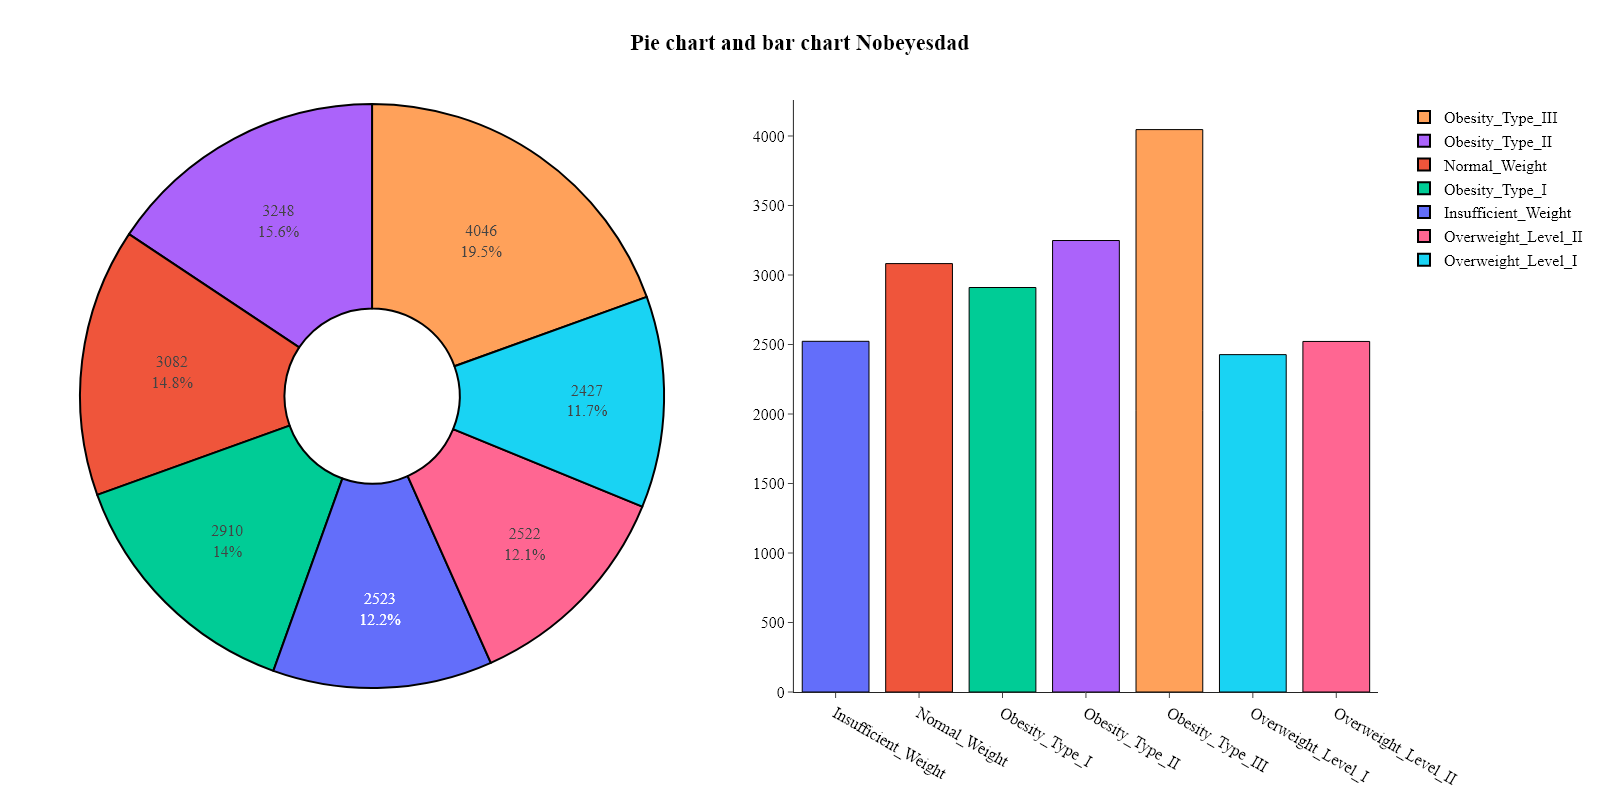

In [9]:
plots.pie_and_bar_plot(data=train_data[target_variable], name=target_variable)

$\text{We have highest number of people with Ovesity\_Type III having share of 19.5\%.}$

### Categorical features

#### Gender

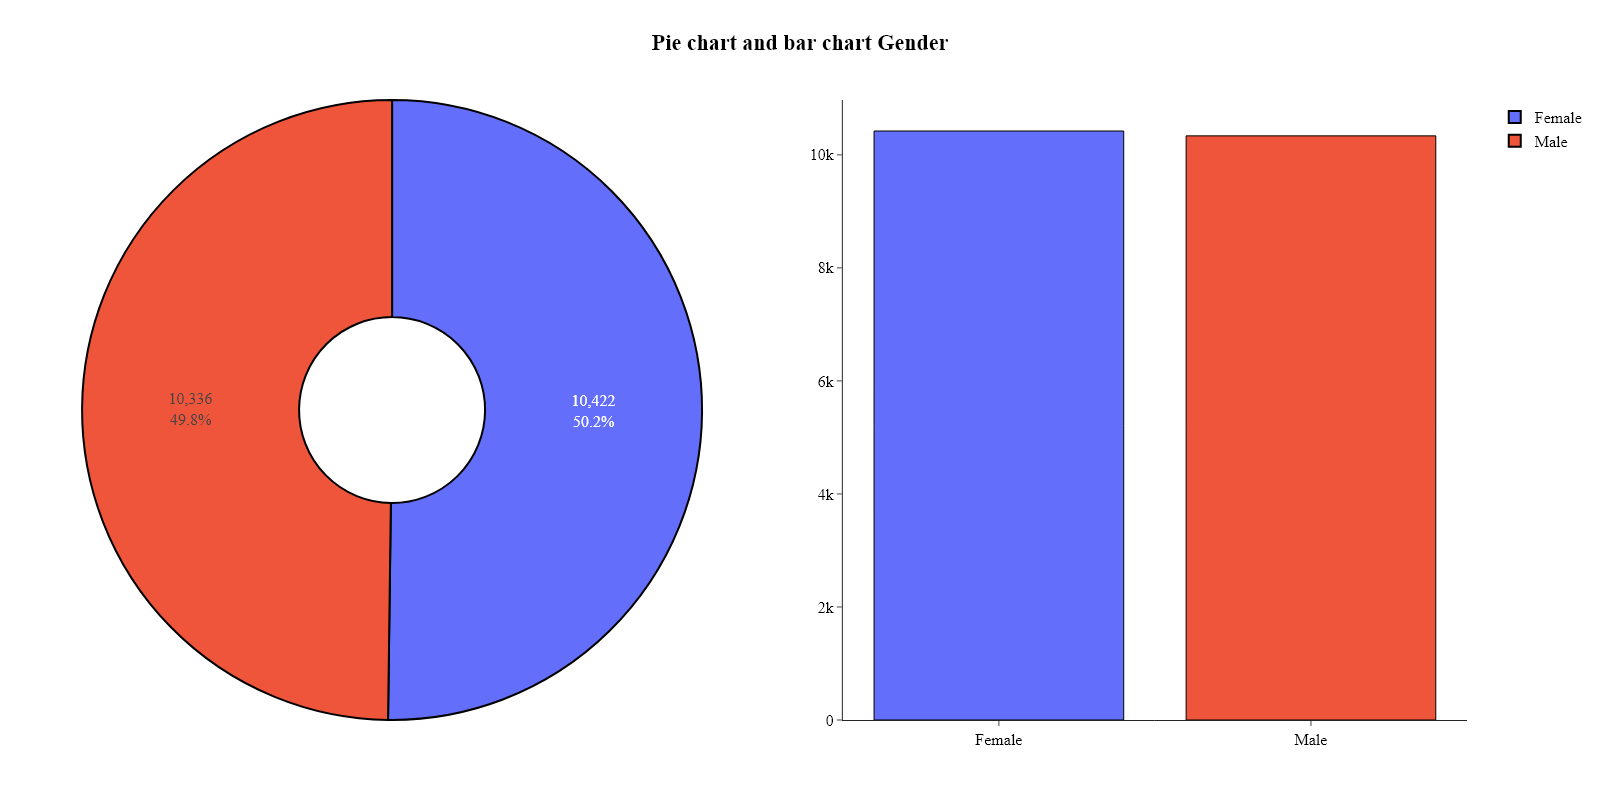

In [10]:
plots.pie_and_bar_plot(data=train_data["Gender"], name="Gender")

$\text{Gender distribution is fairly equal in the dataset.}$

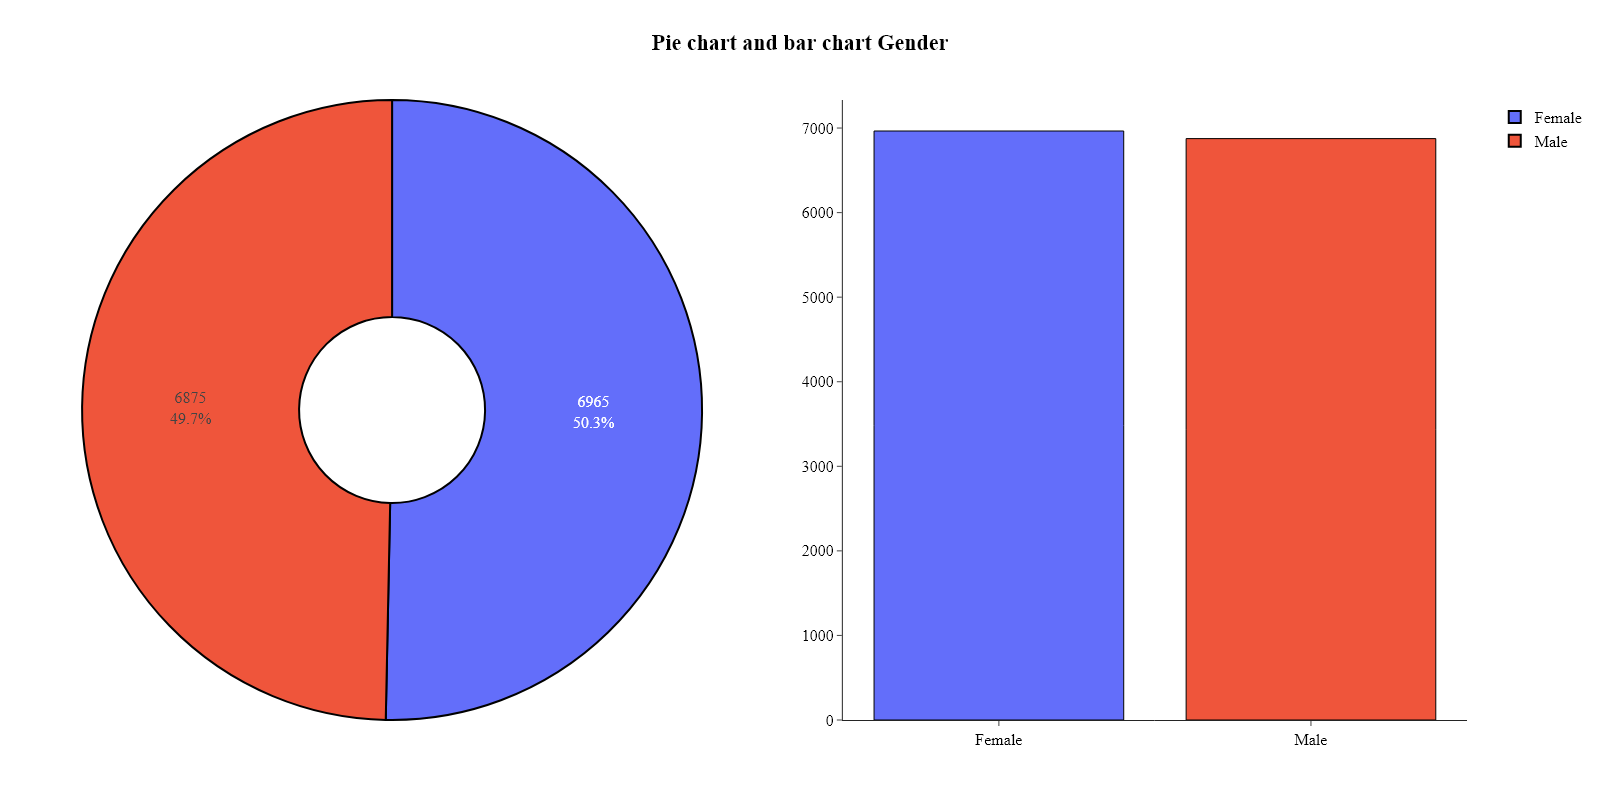

In [11]:
plots.pie_and_bar_plot(data=test_data["Gender"], name="Gender")

#### family_history_with_overweight

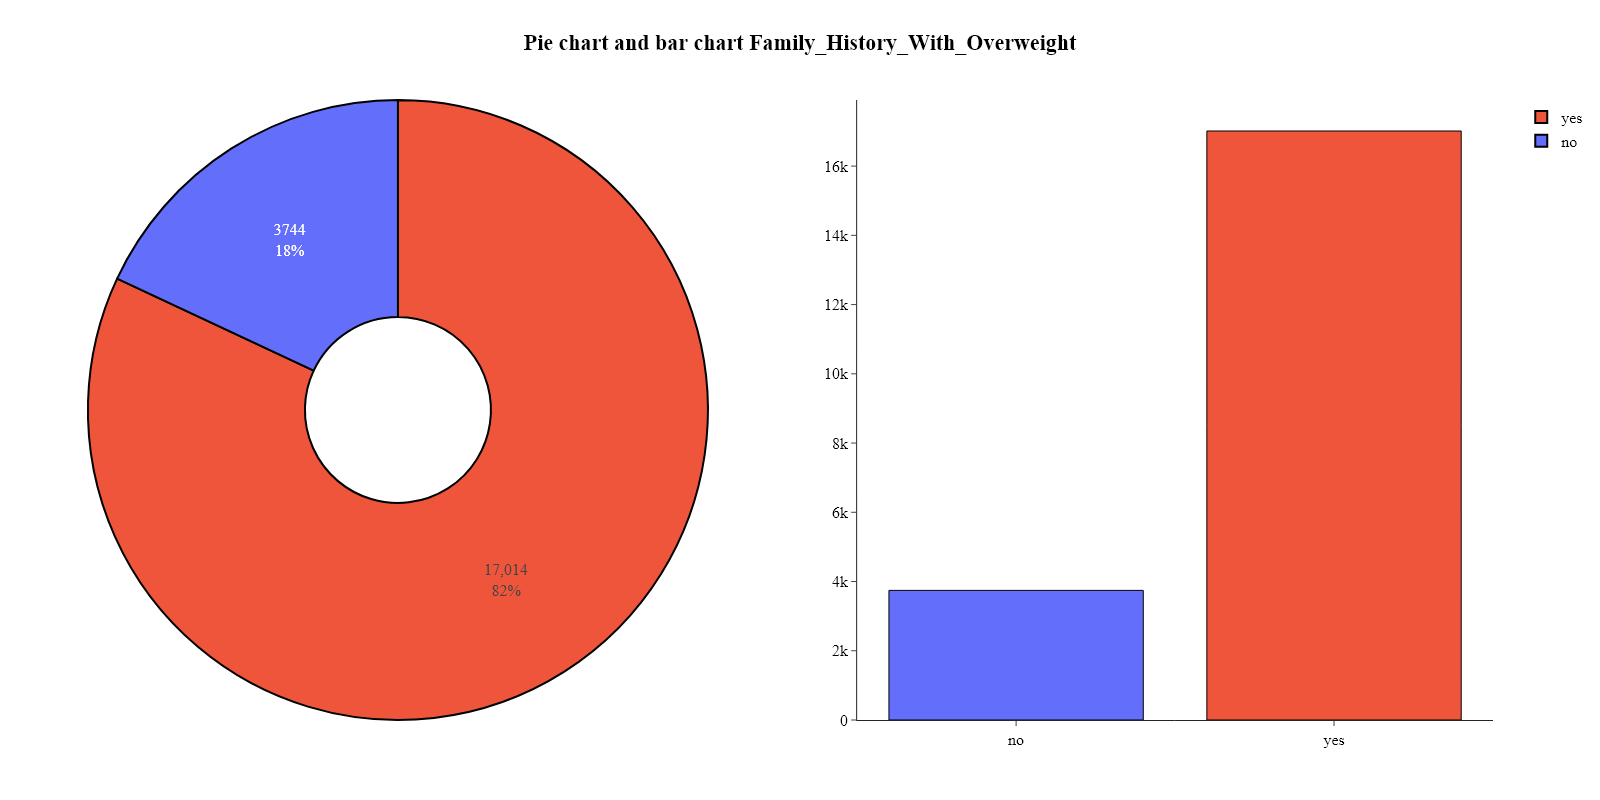

In [12]:
plots.pie_and_bar_plot(data=train_data["family_history_with_overweight"], name="family_history_with_overweight")

$\text{82.0\% people have a family history with Overweight.}$

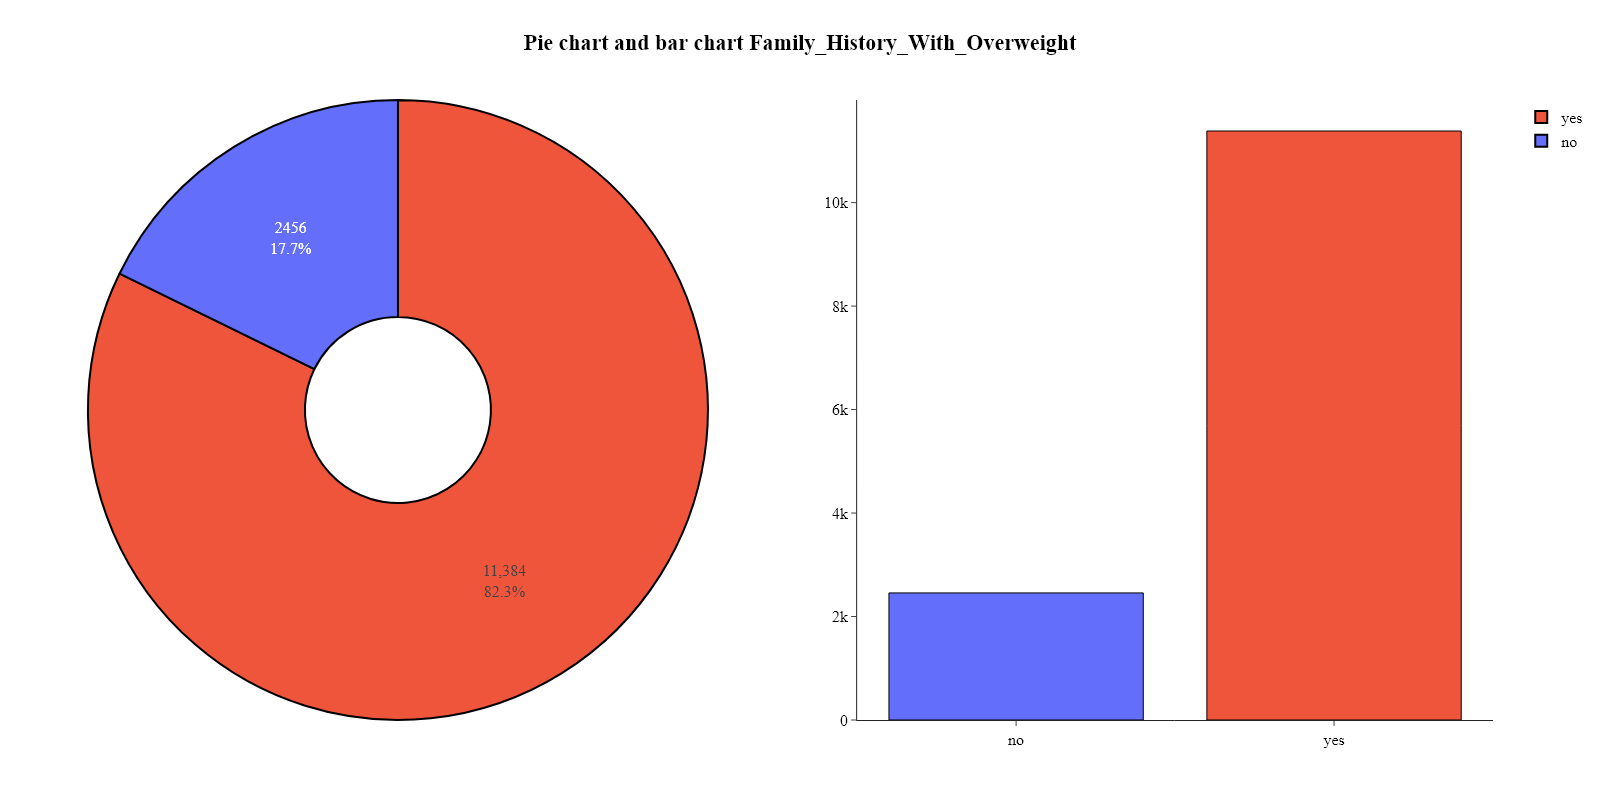

In [13]:
plots.pie_and_bar_plot(data=test_data["family_history_with_overweight"], name="family_history_with_overweight")

#### FAVC

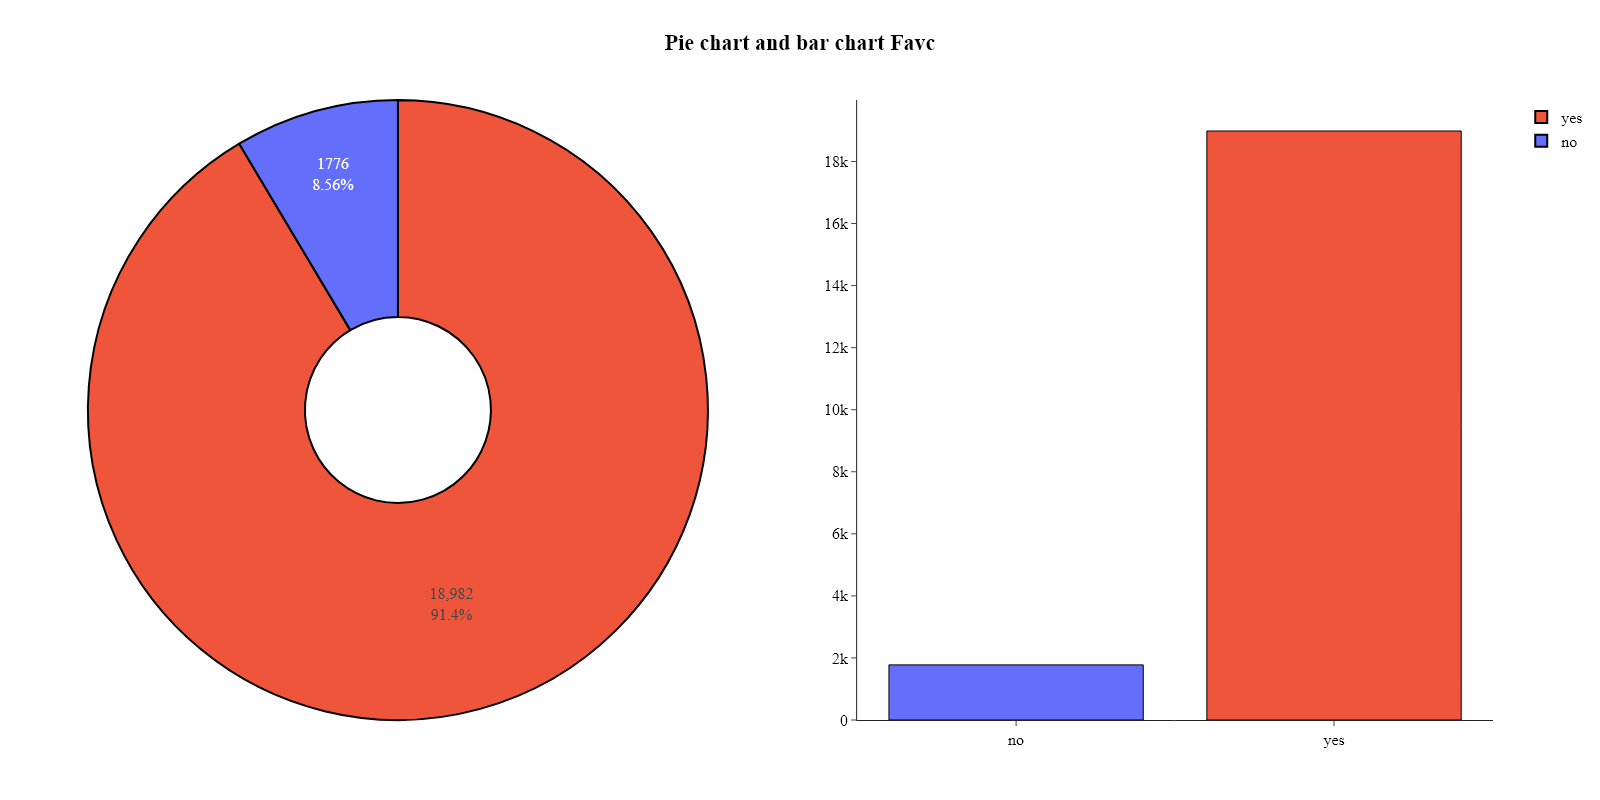

In [14]:
plots.pie_and_bar_plot(data=train_data["FAVC"], name="FAVC")

$\text{91.4\% people Frequently consume high caloric food.}$

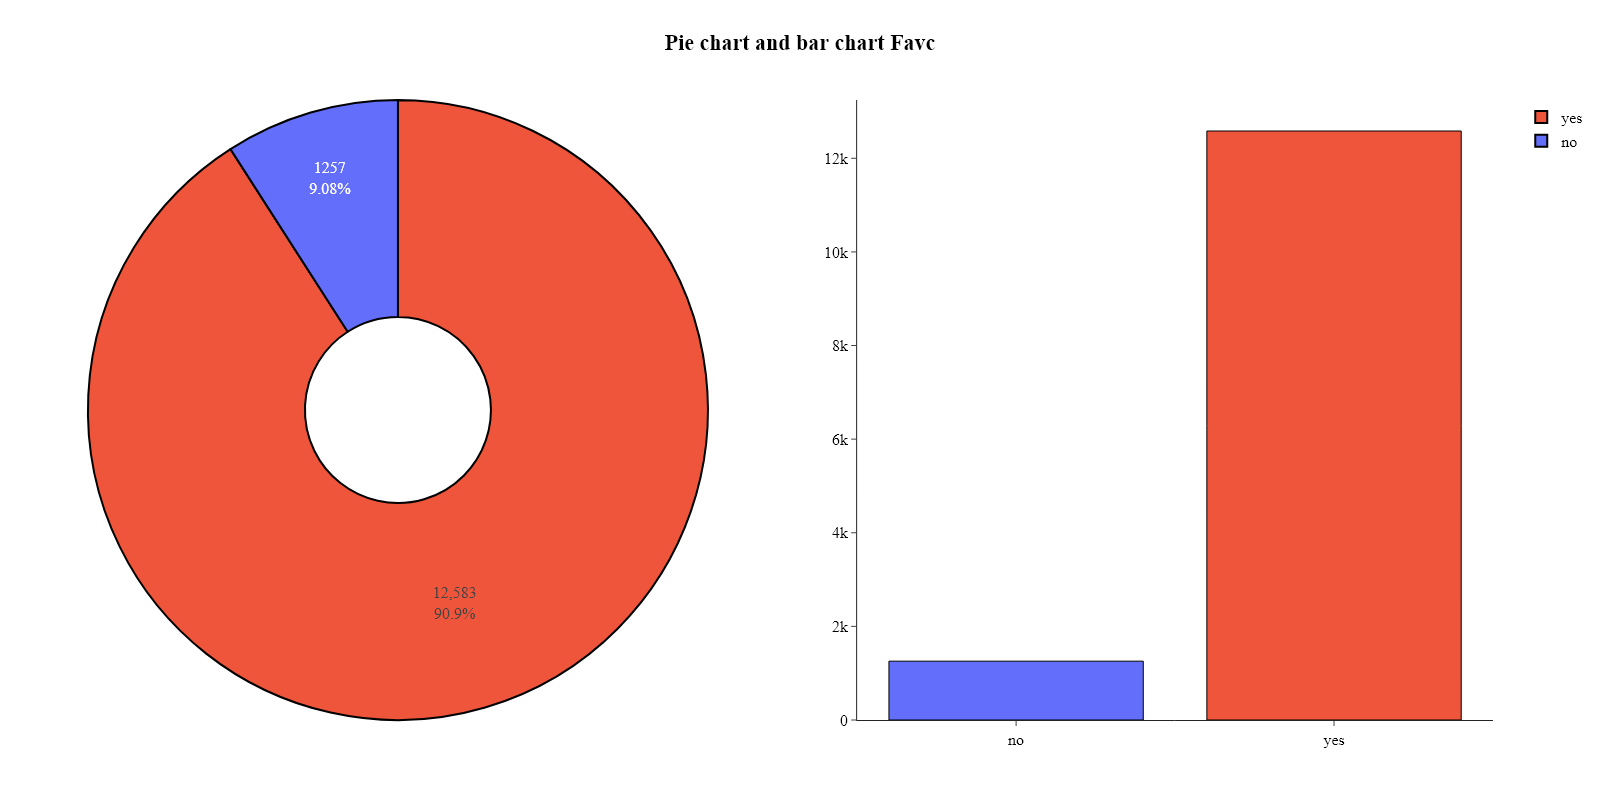

In [15]:
plots.pie_and_bar_plot(data=test_data["FAVC"], name="FAVC")

#### CAEC

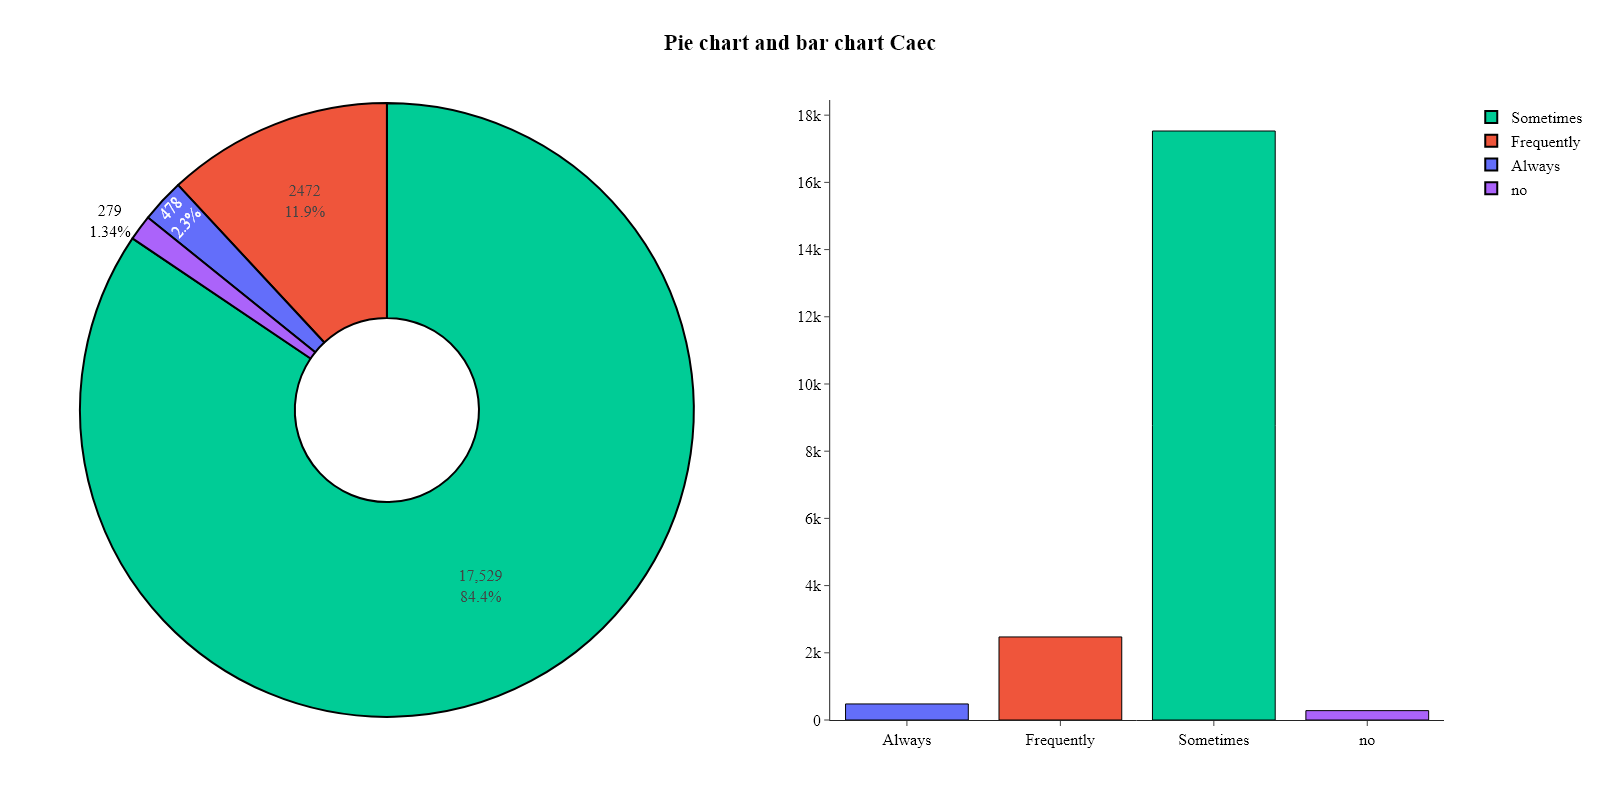

In [16]:
plots.pie_and_bar_plot(data=train_data["CAEC"], name="CAEC")

$\text{84.4\% sometimes consumes food between meals while ~1.5\% says No meals in between.}$

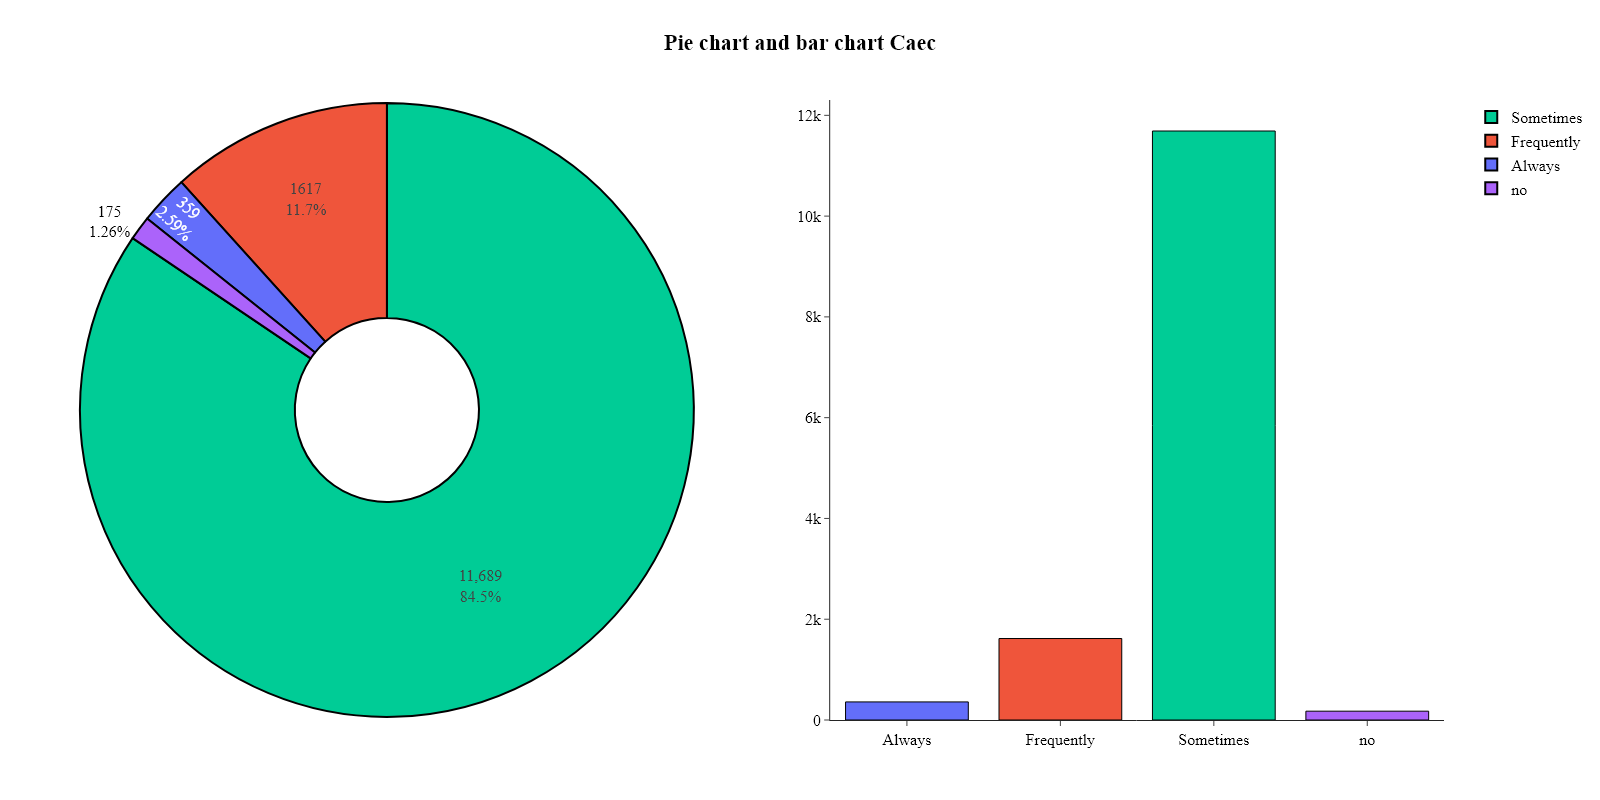

In [17]:
plots.pie_and_bar_plot(data=test_data["CAEC"], name="CAEC")

#### SMOKE

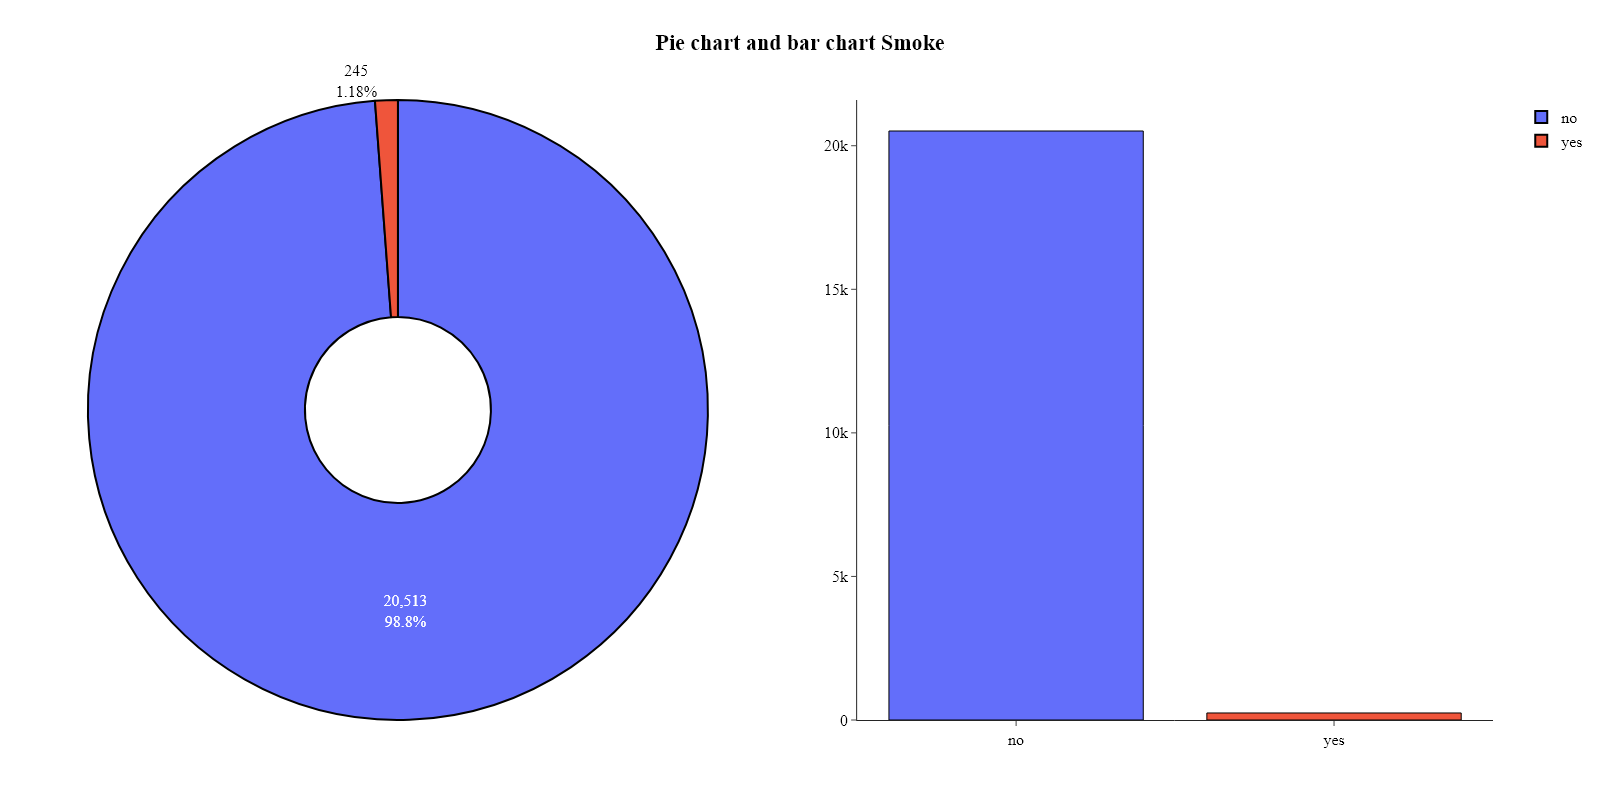

In [18]:
plots.pie_and_bar_plot(data=train_data["SMOKE"], name="SMOKE")

$\text{98.8\% are non-Smokers. Doesn't sound correct, but let's trust the data.}$

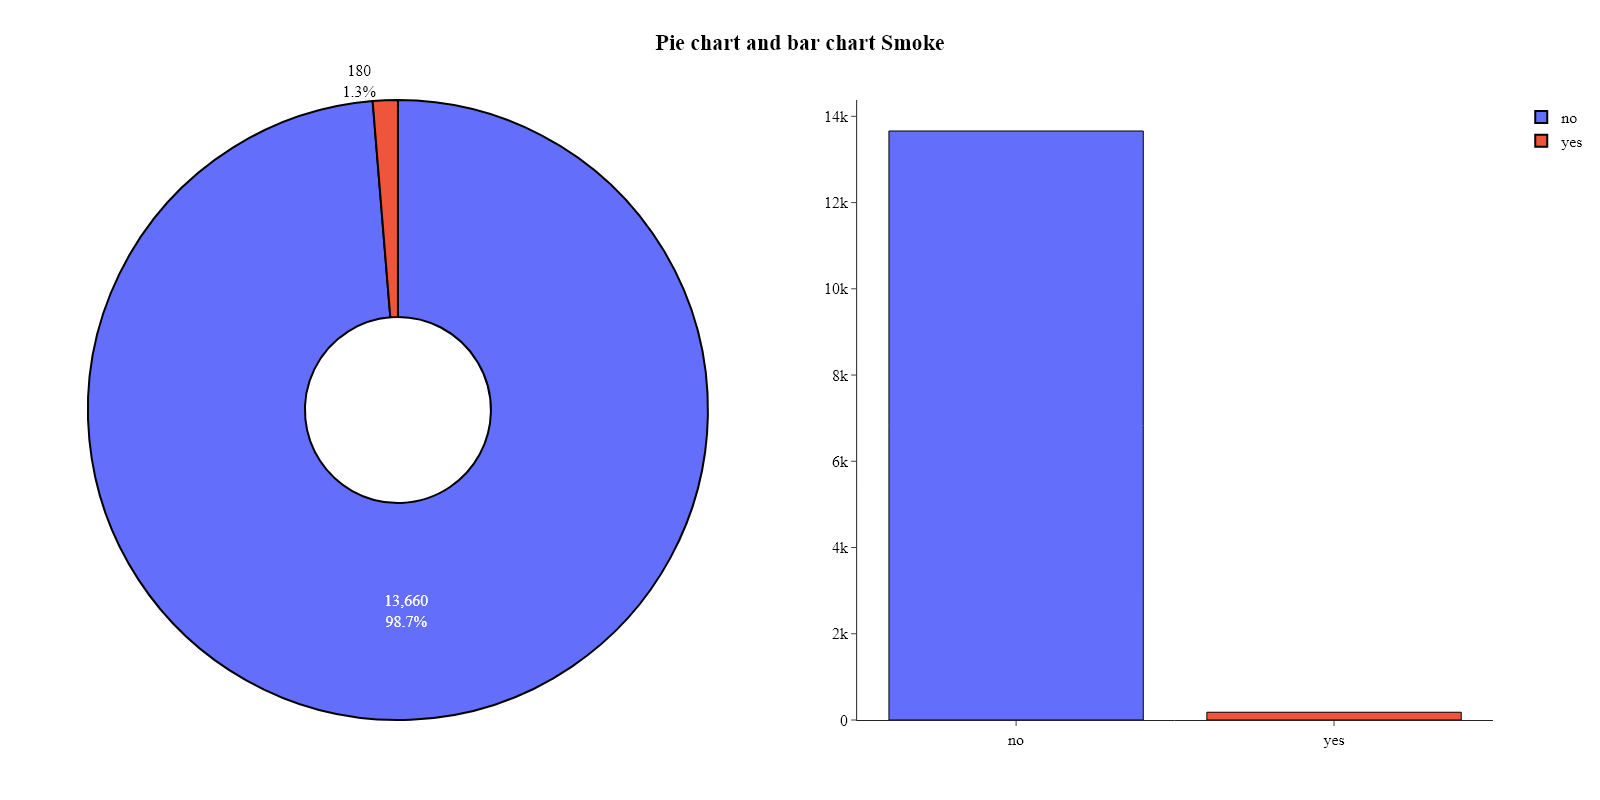

In [19]:
plots.pie_and_bar_plot(data=test_data["SMOKE"], name="SMOKE")

#### SCC

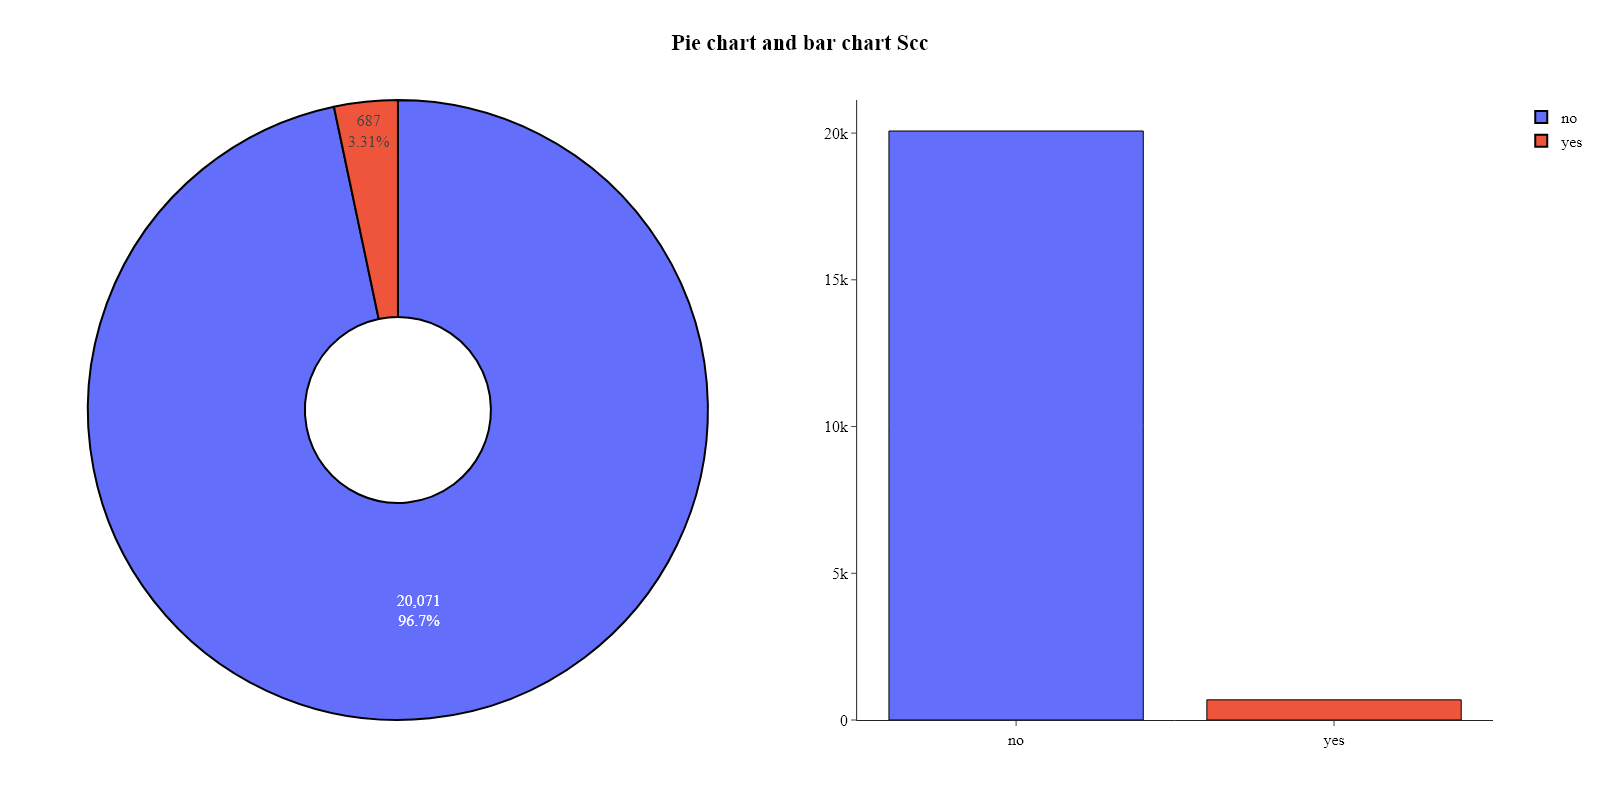

In [20]:
plots.pie_and_bar_plot(data=train_data["SCC"], name="SCC")

$\text{96.7\% don't bother monitoring calorie consumption.}$

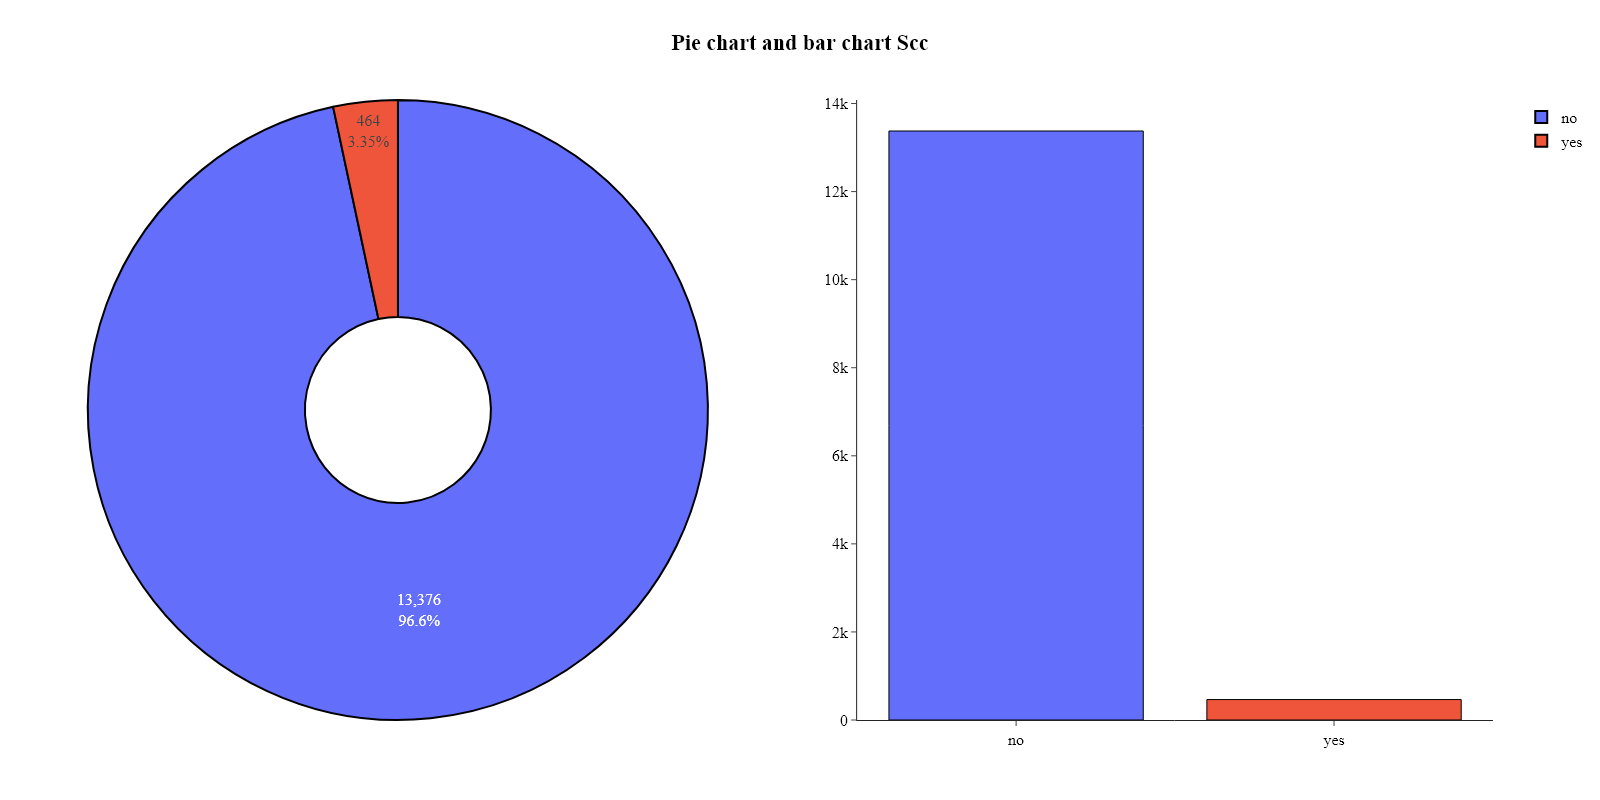

In [21]:
plots.pie_and_bar_plot(data=test_data["SCC"], name="SCC")

#### CALC

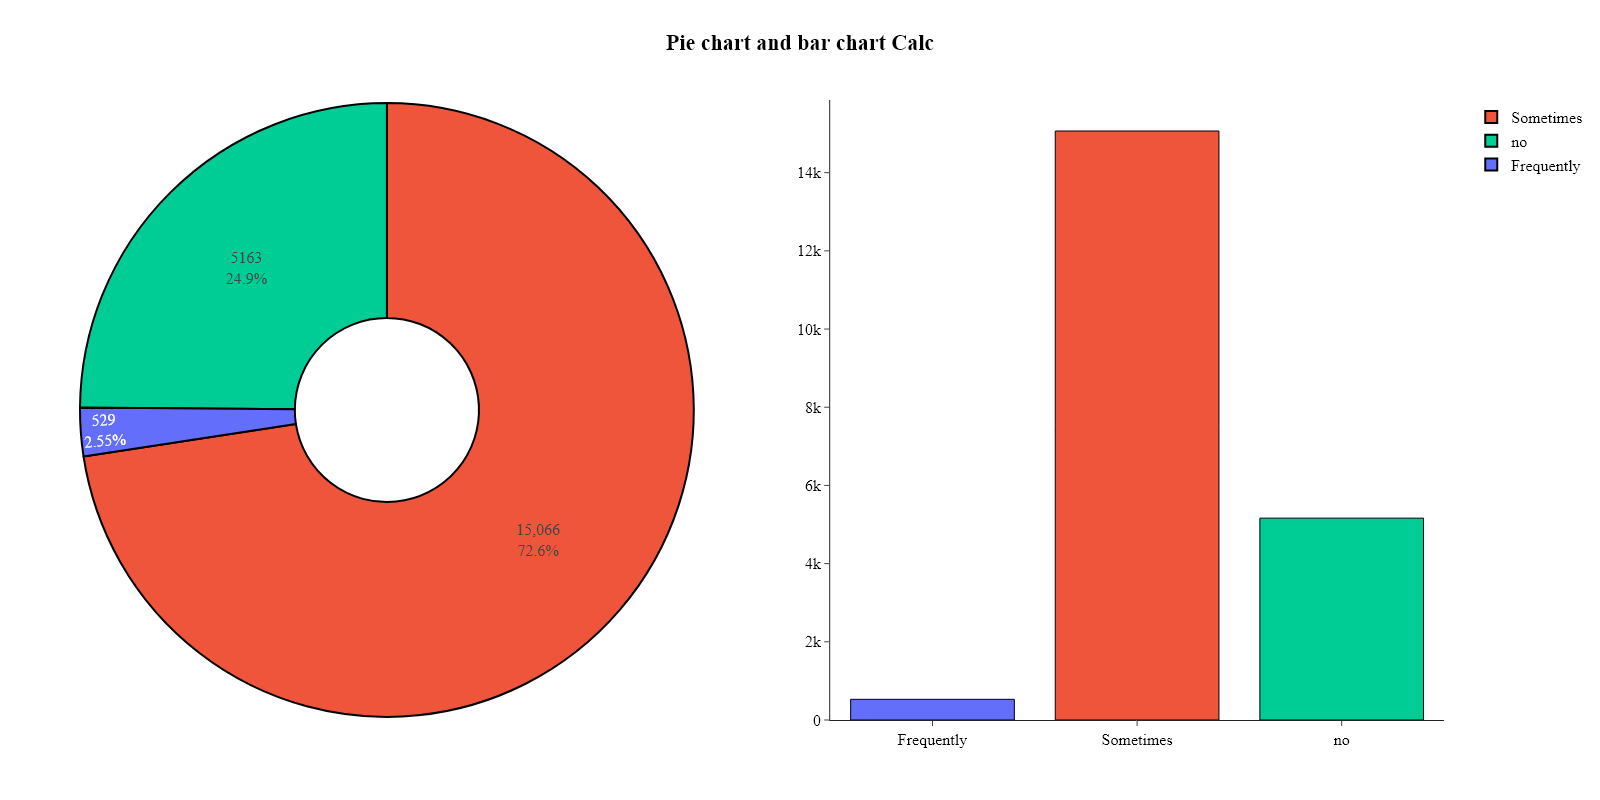

In [22]:
plots.pie_and_bar_plot(data=train_data["CALC"], name="CALC")

$\text{72.6\% consumes alcohol sometimes while 2.5\% does Frequent.}$

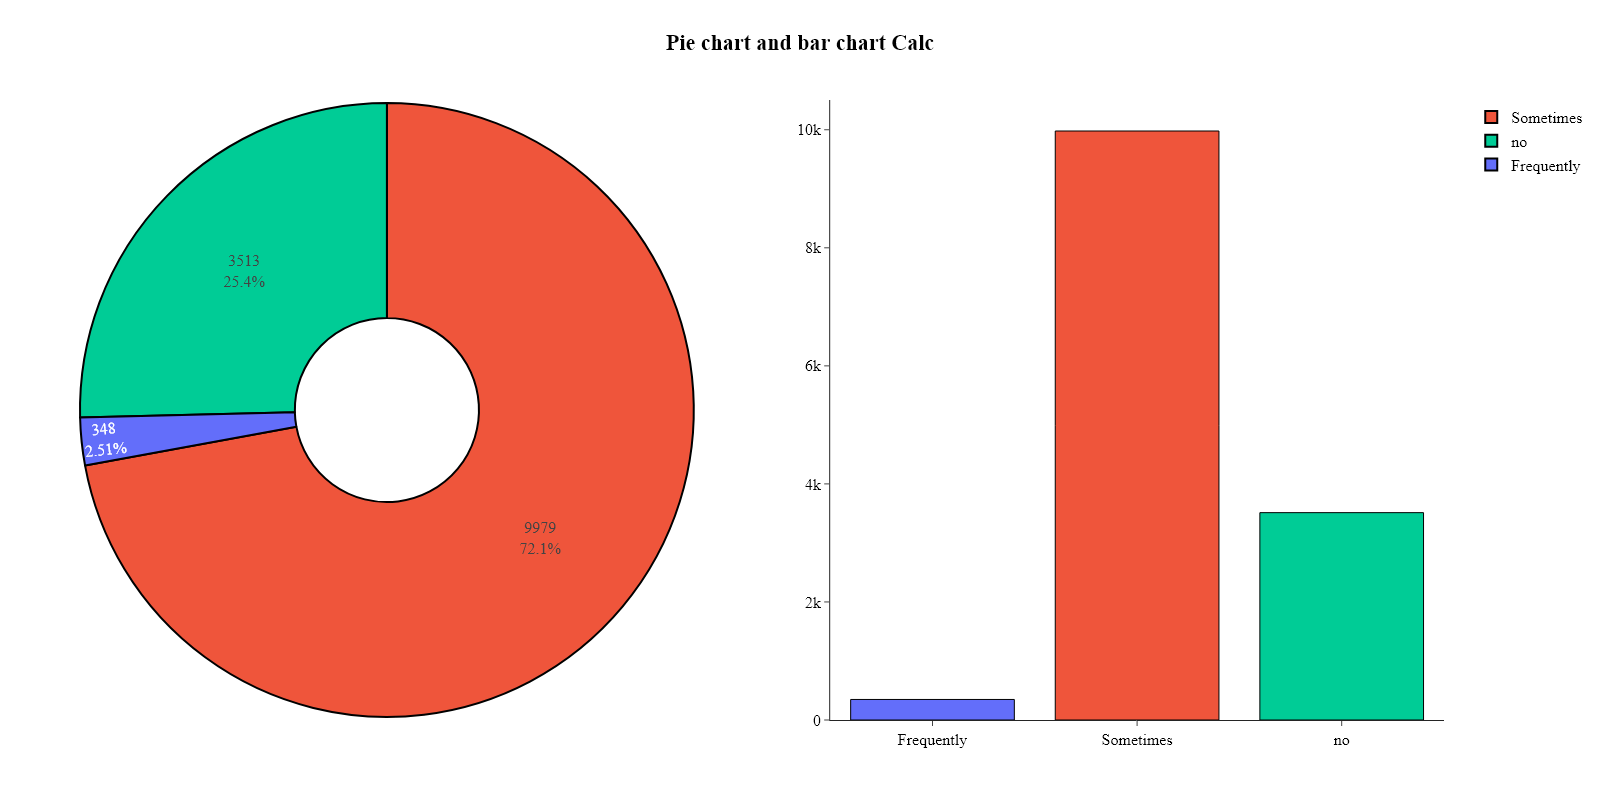

In [23]:
plots.pie_and_bar_plot(data=test_data["CALC"], name="CALC")

#### MTRANS

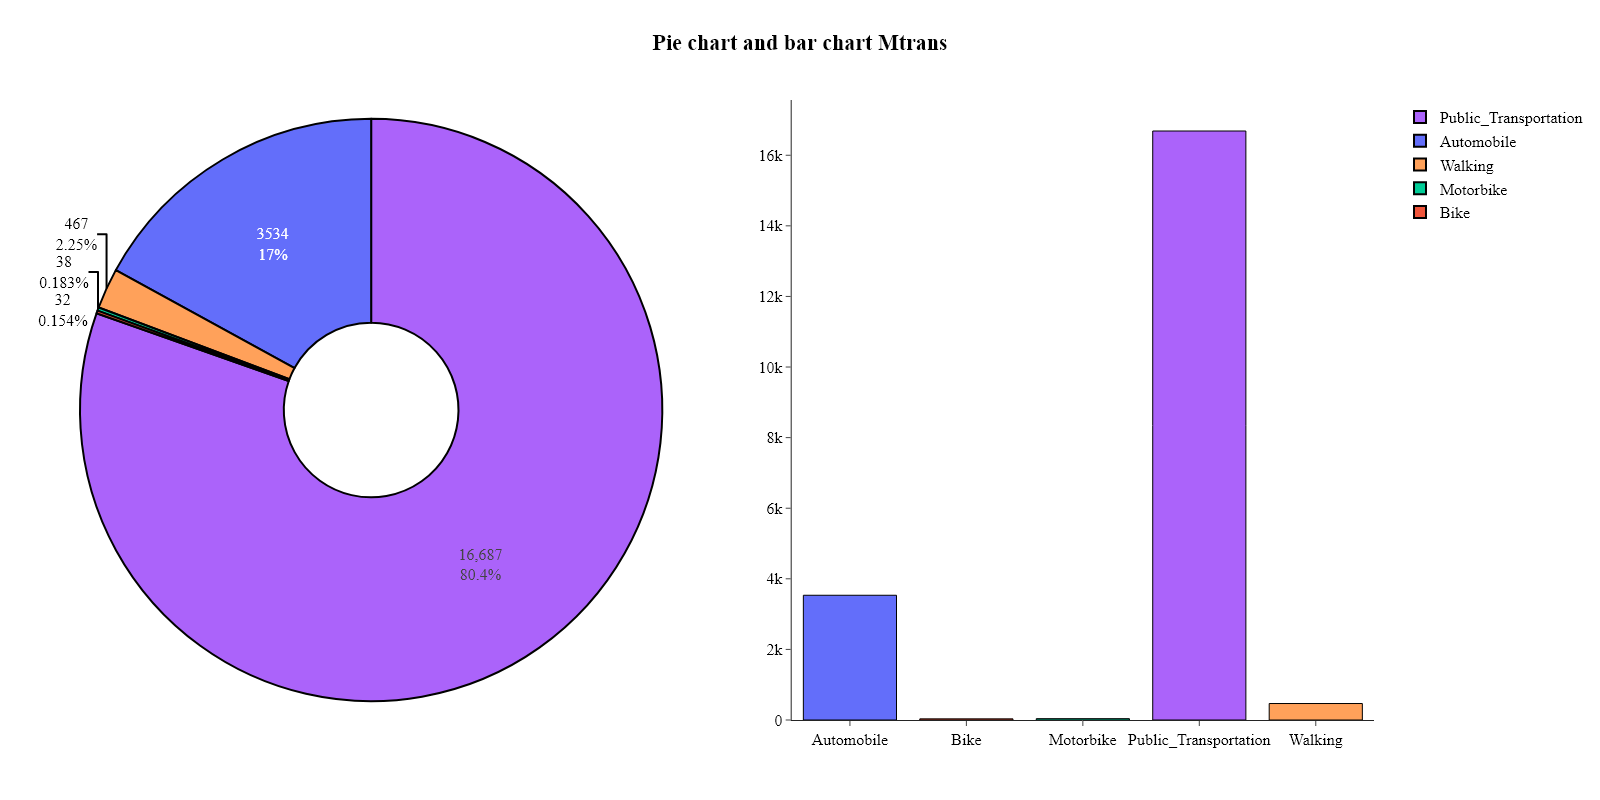

In [24]:
plots.pie_and_bar_plot(data=train_data["MTRANS"], name="MTRANS")

$\text{97.6\% use some form of vehicles while only ~2.4\% prefers walking/using bike That's concerning!}$

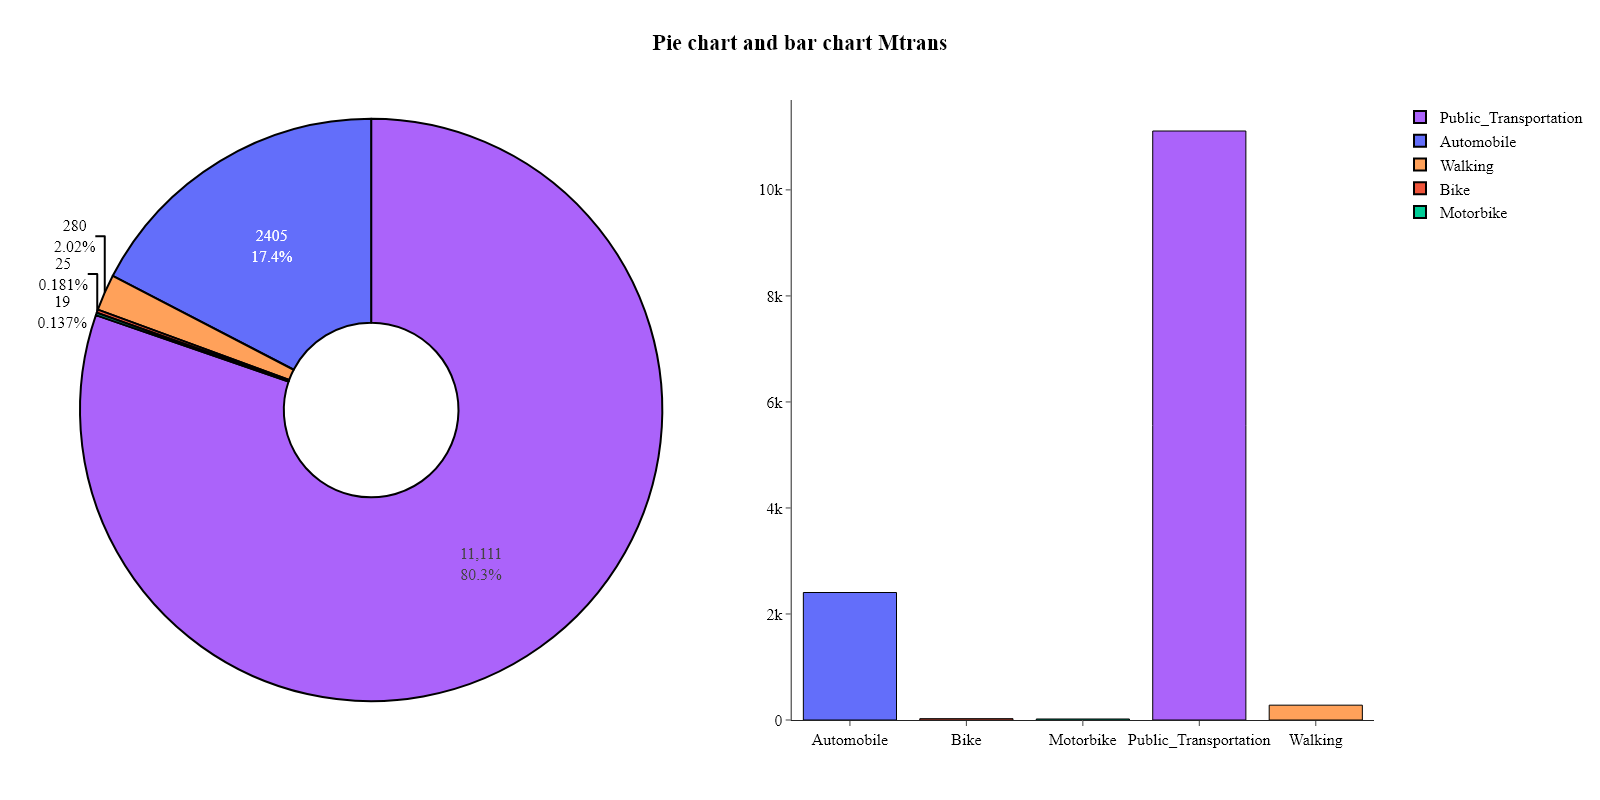

In [25]:
plots.pie_and_bar_plot(data=test_data["MTRANS"], name="MTRANS")

$\text{Distirbution of categorical features is fairly equal in train and test datasets.}$

### Continous features

#### Age

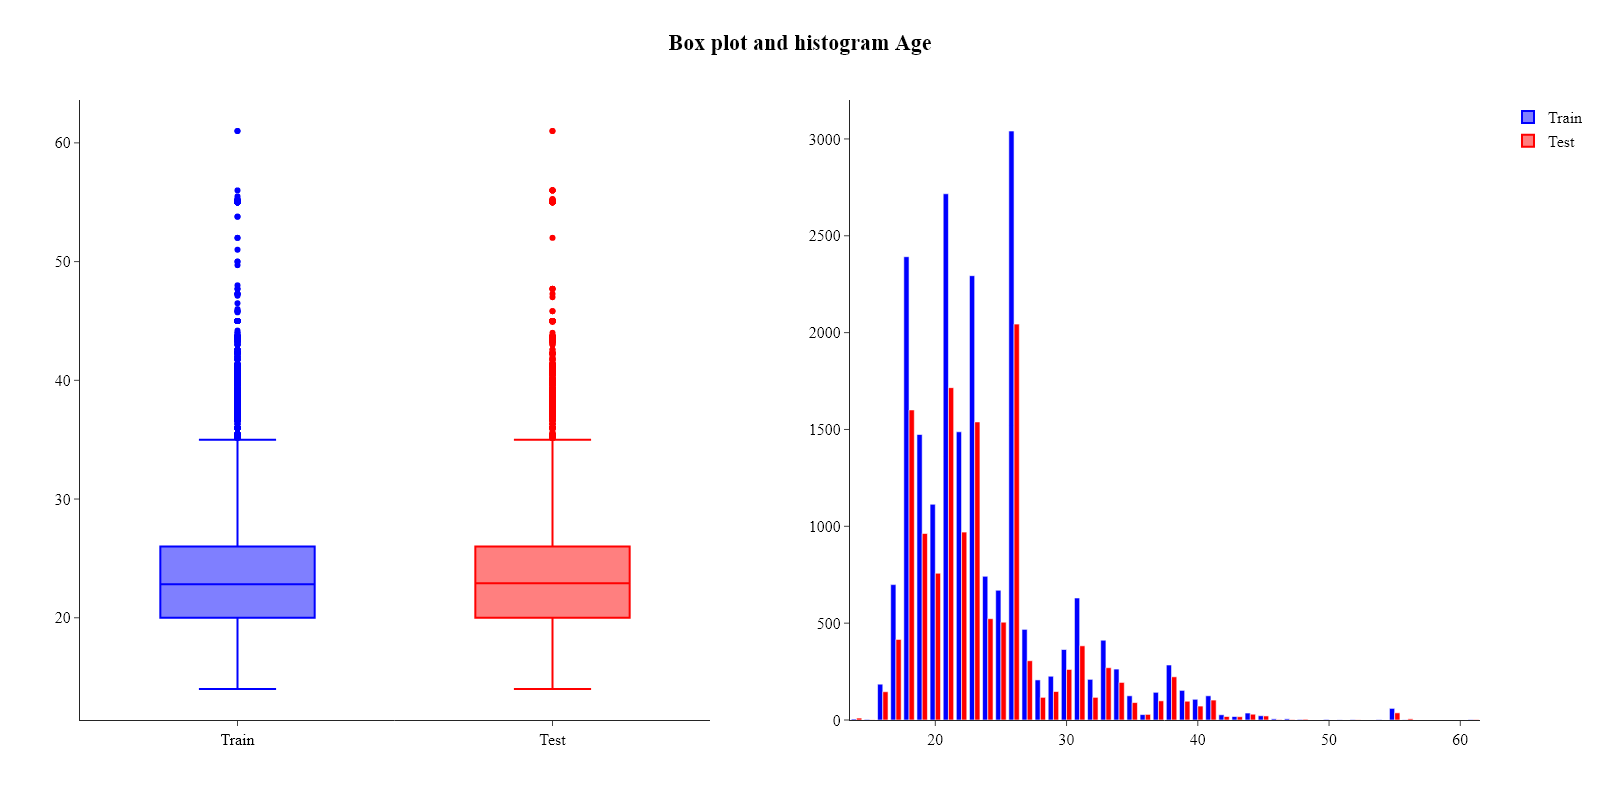

In [26]:
plots.box_and_hist_plot(train=train_data["Age"], test=test_data["Age"], name="Age", bin_size=1)

$\text{Data is a little bit right-skewed.}$

#### Height

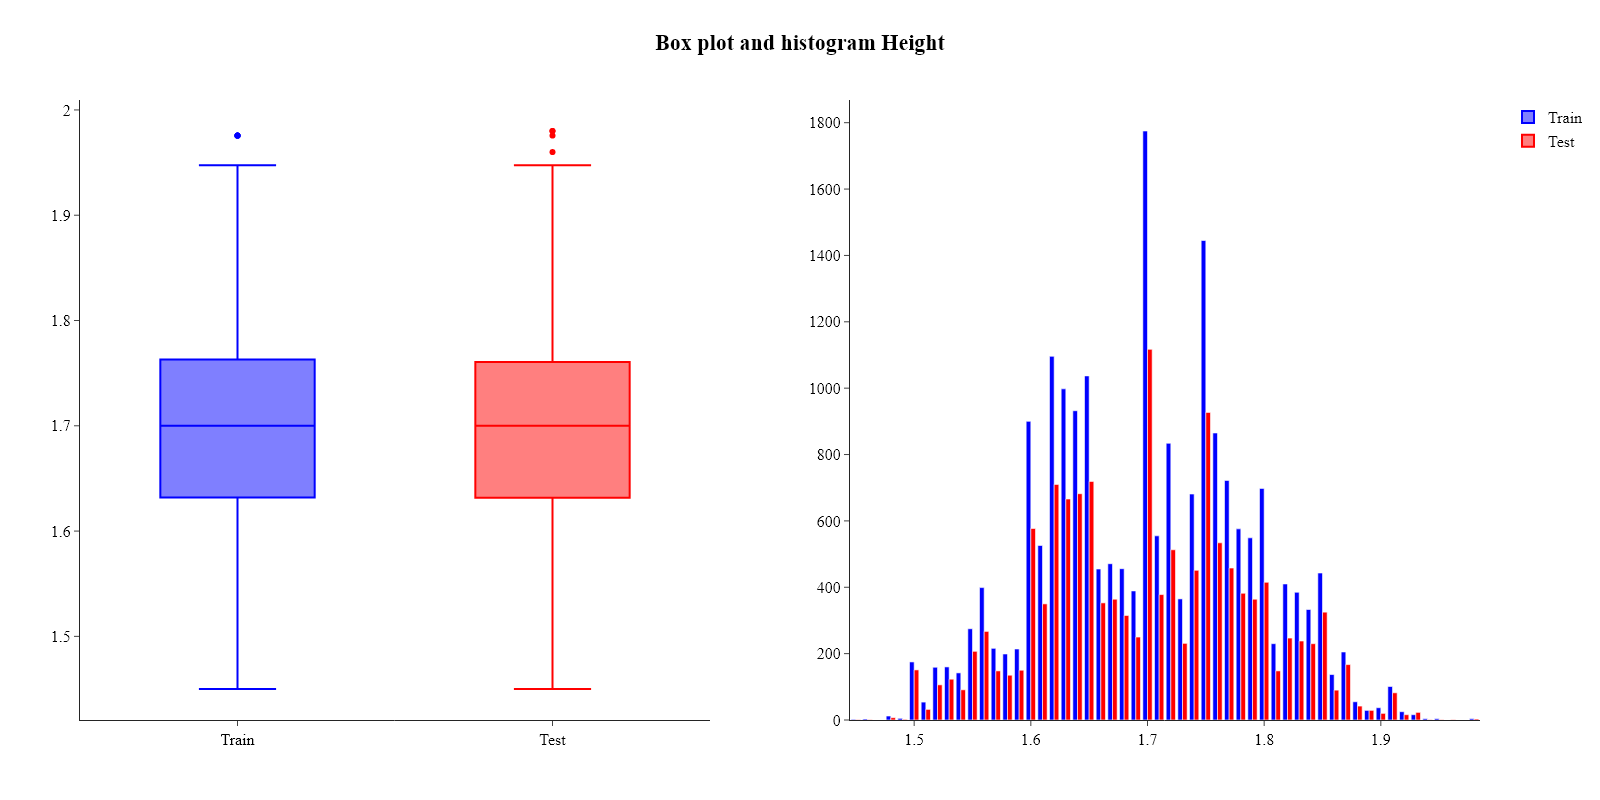

In [27]:
plots.box_and_hist_plot(train=train_data["Height"], test=test_data["Height"], name="Height", bin_size=0.01)

$\text{Data is similar to a normal distribution.}$

#### Weight

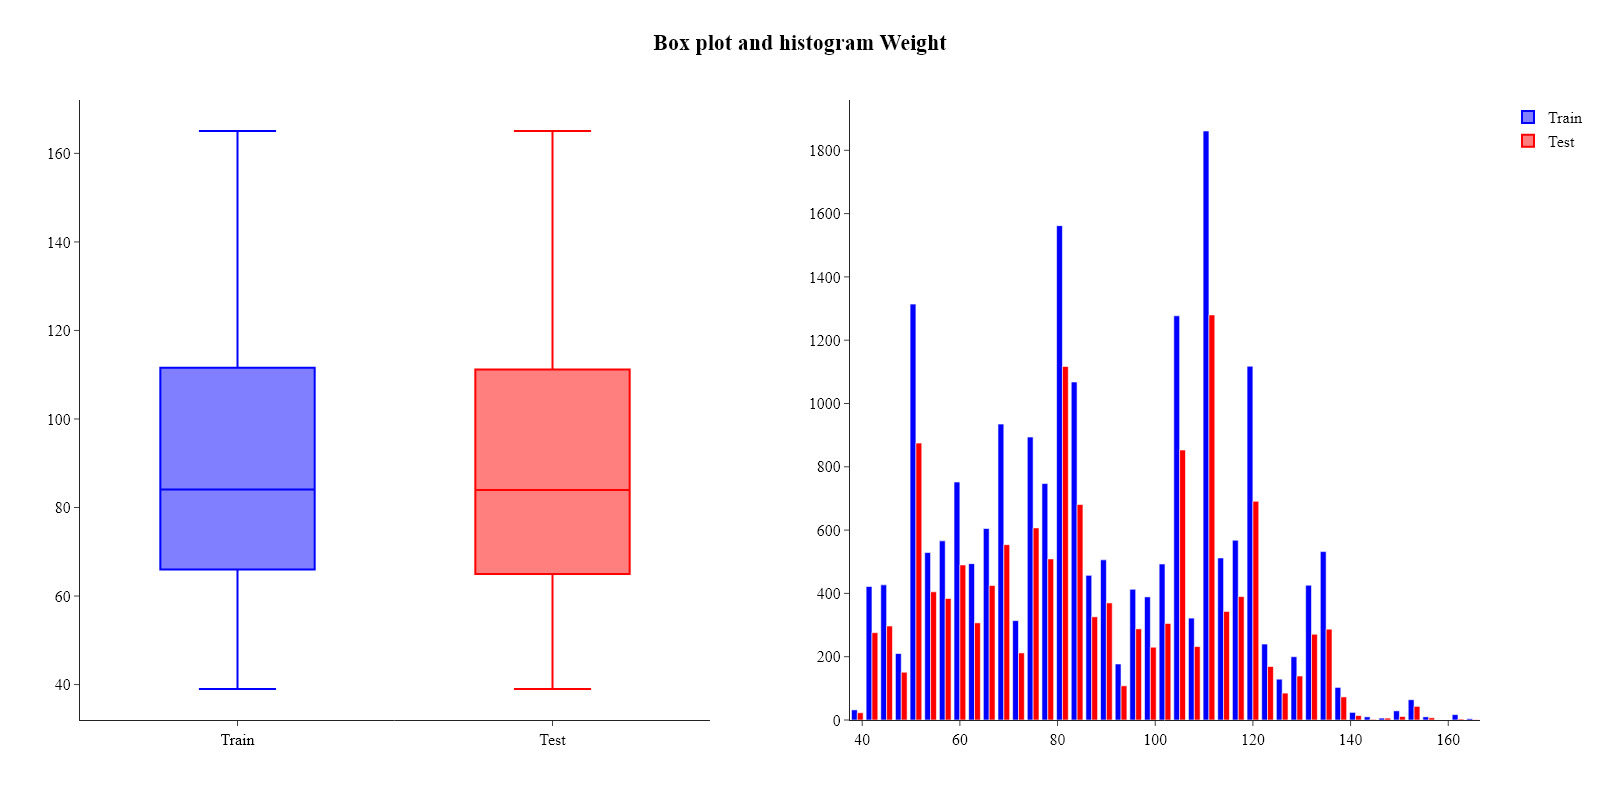

In [28]:
plots.box_and_hist_plot(train=train_data["Weight"], test=test_data["Weight"], name="Weight", bin_size=3)

#### FCVC

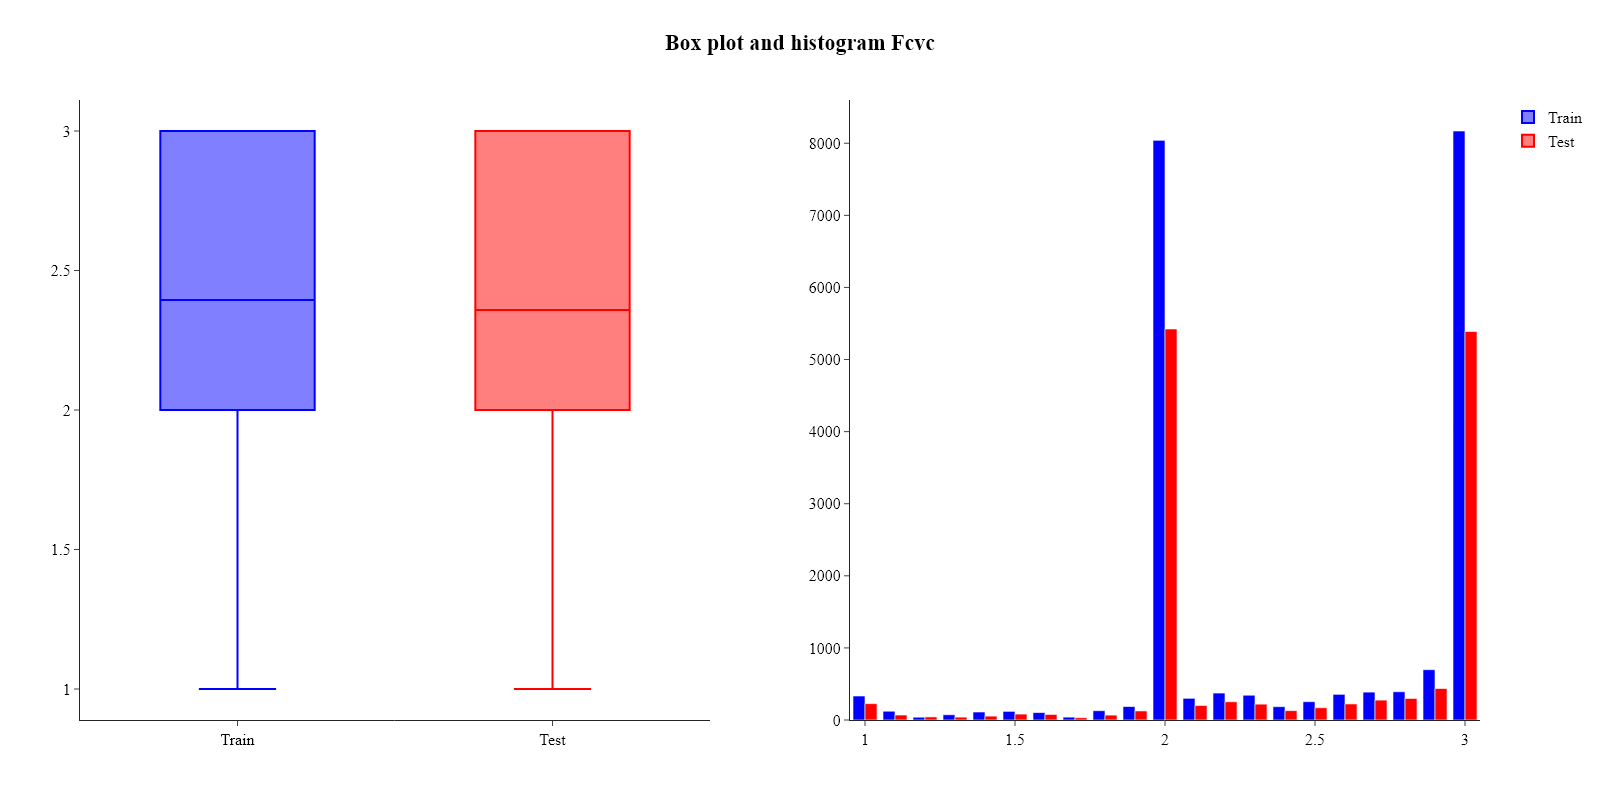

In [29]:
plots.box_and_hist_plot(train=train_data["FCVC"], test=test_data["FCVC"], name="FCVC", bin_size=0.1)

$\text{Data has awkward distribution.}$

#### NCP

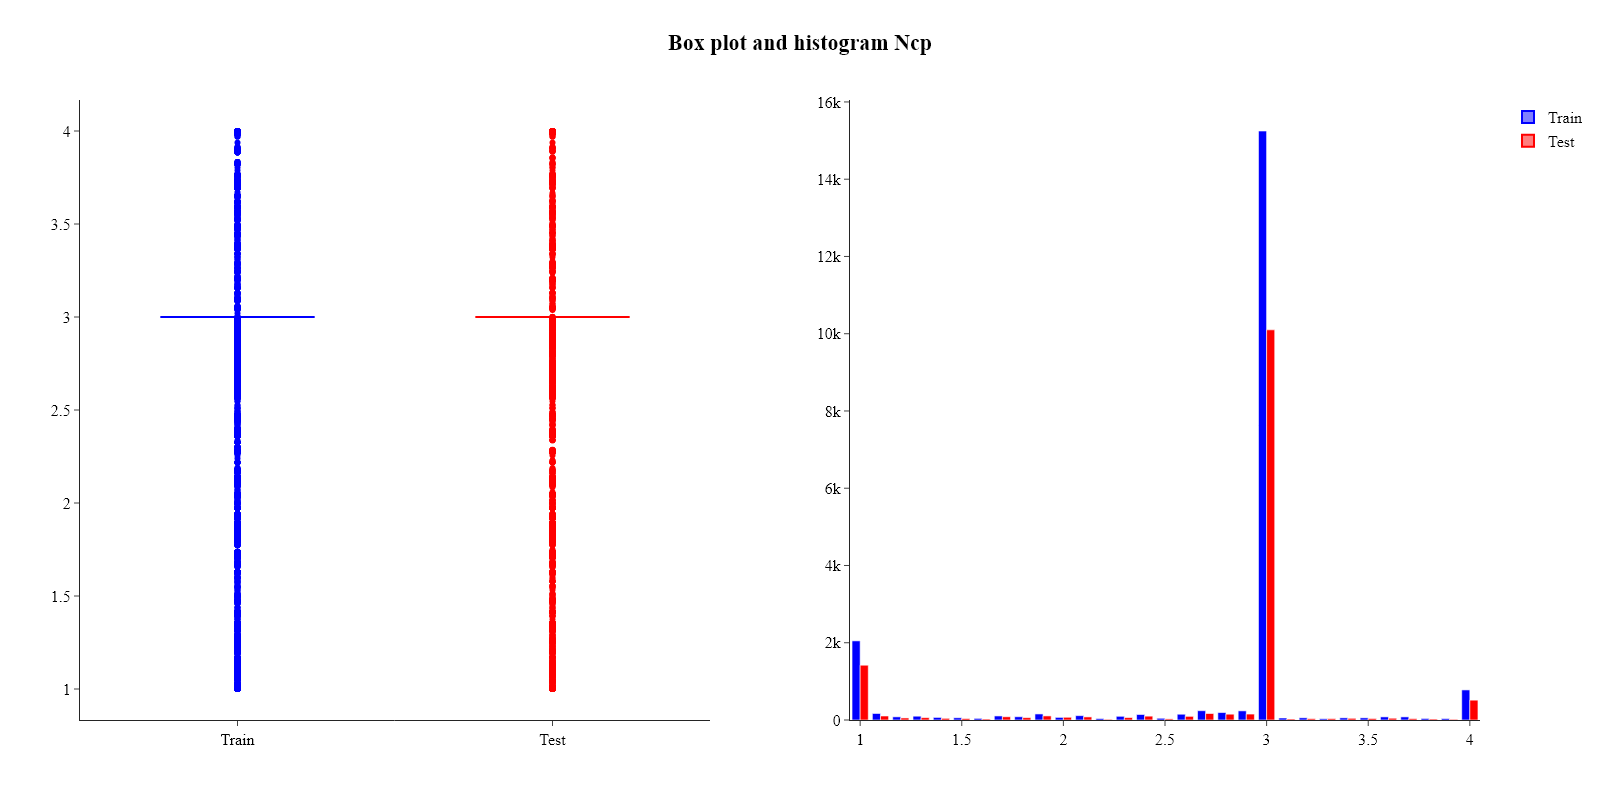

In [30]:
plots.box_and_hist_plot(train=train_data["NCP"], test=test_data["NCP"], name="NCP", bin_size=0.1)

$\text{Data has awkward distribution.}$

#### CH2O

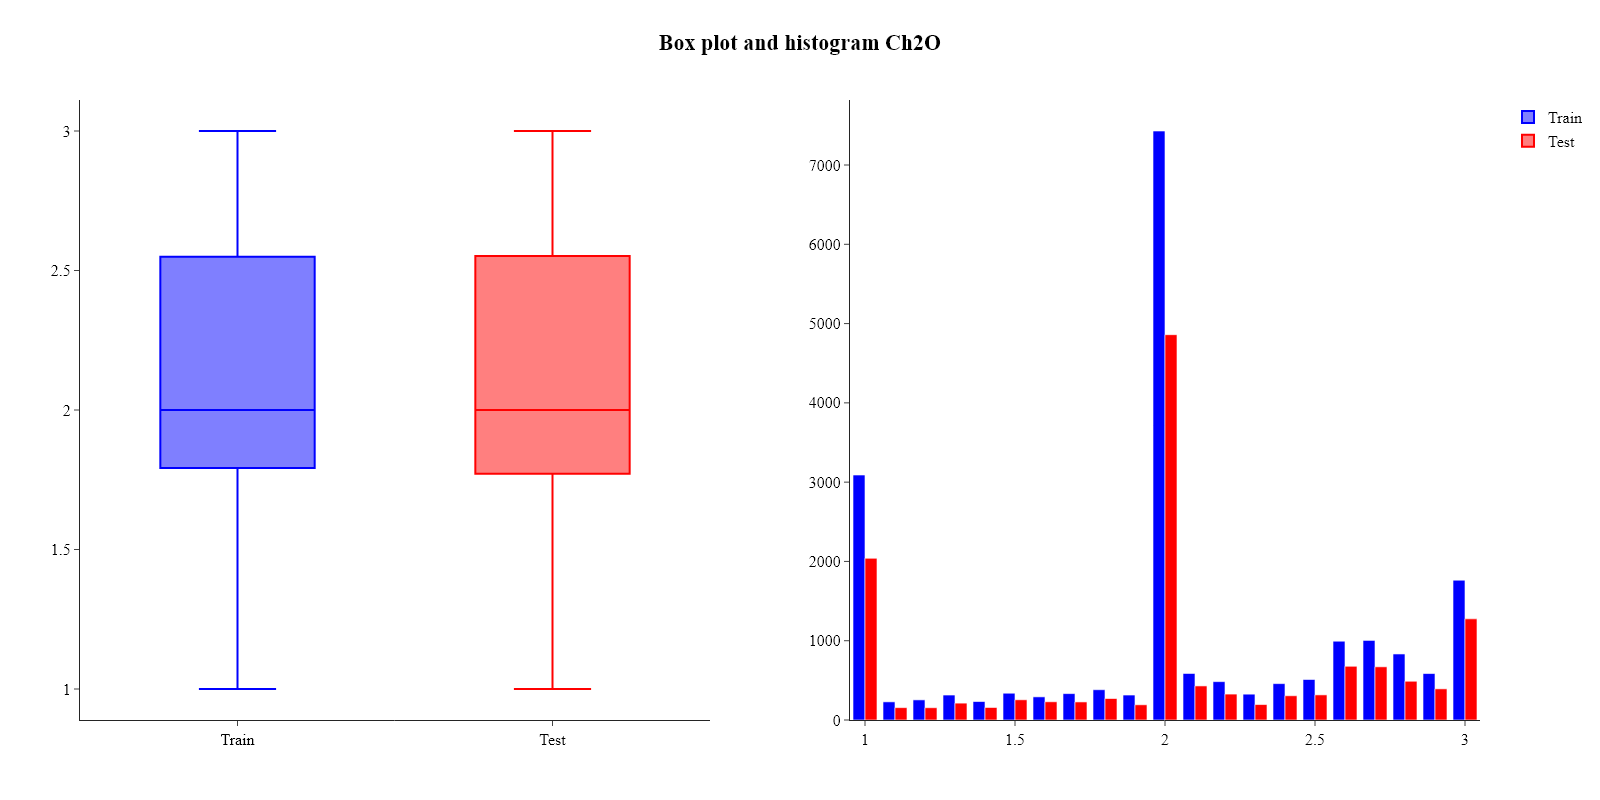

In [31]:
plots.box_and_hist_plot(train=train_data["CH2O"], test=test_data["CH2O"], name="CH2O", bin_size=0.1)

$\text{Data has awkward distribution.}$

#### FAF

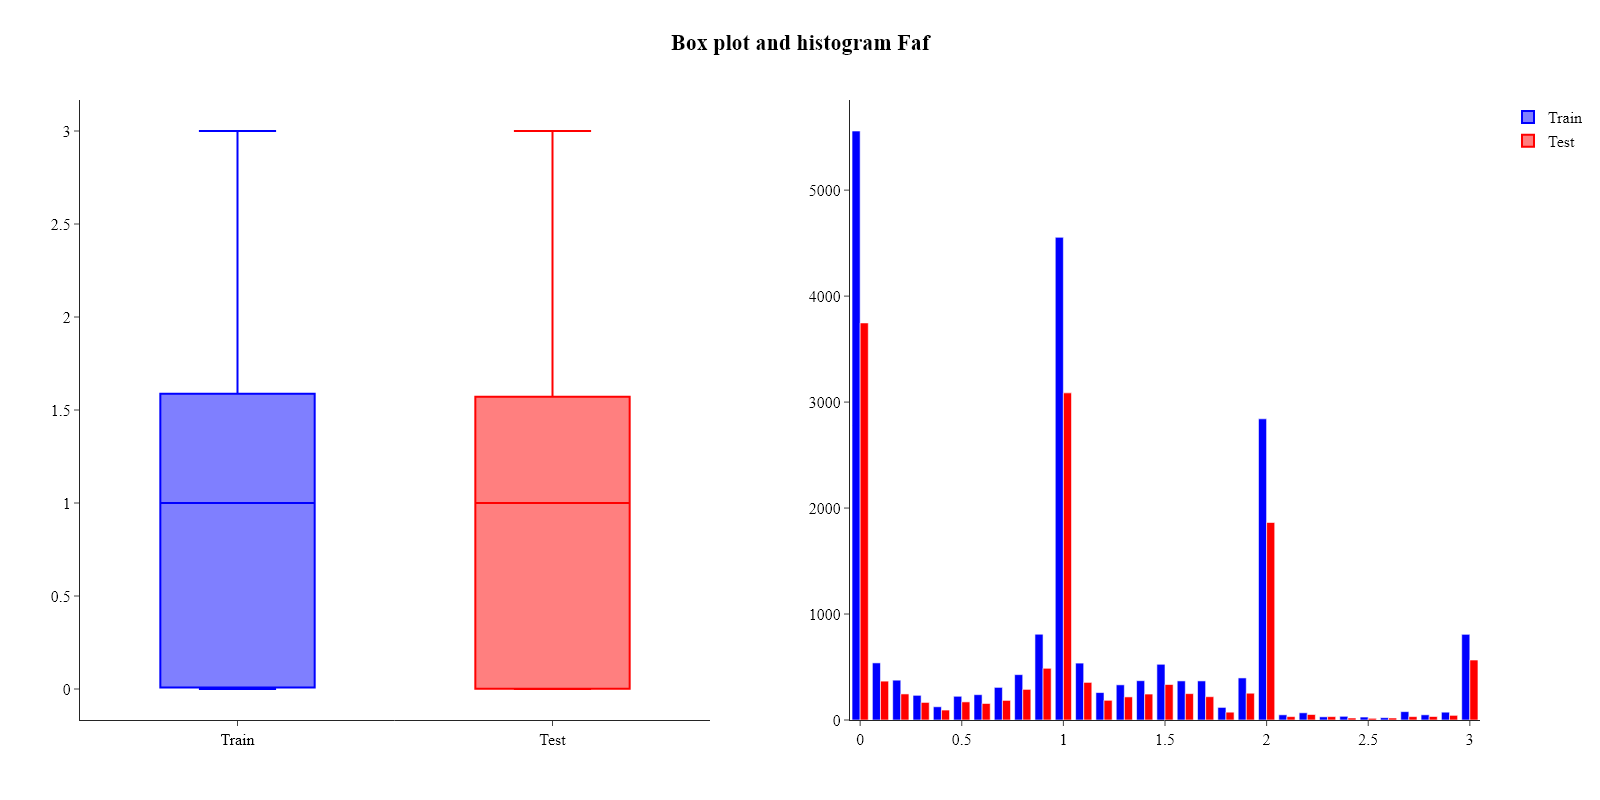

In [32]:
plots.box_and_hist_plot(train=train_data["FAF"], test=test_data["FAF"], name="FAF", bin_size=0.1)

$\text{Data is right-skewed distributed.}$

#### TUE

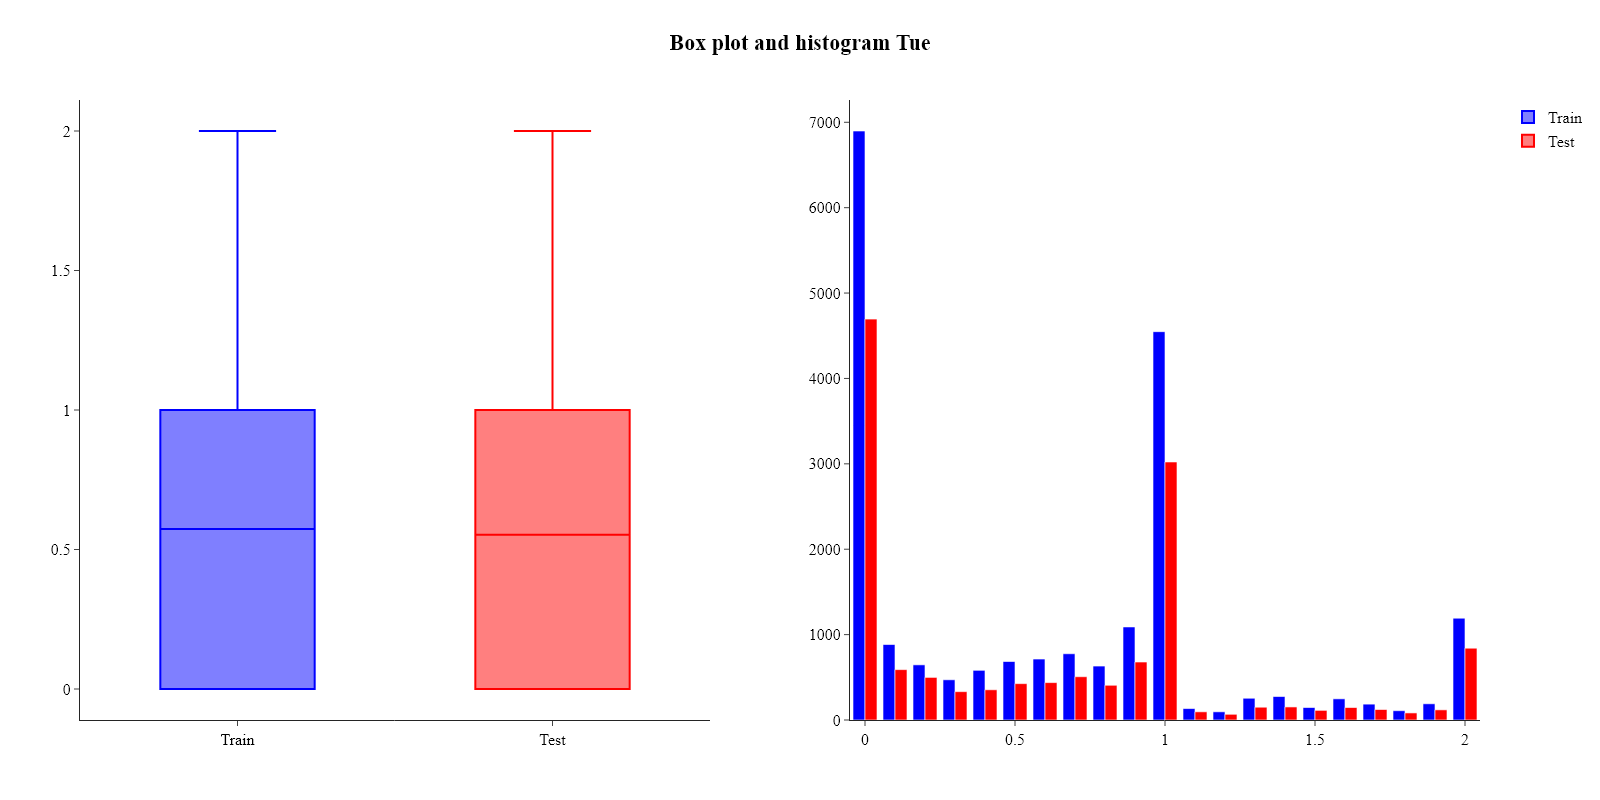

In [33]:
plots.box_and_hist_plot(train=train_data["TUE"], test=test_data["TUE"], name="TUE", bin_size=0.1)

$\text{Data is right-skewed distributed.}$

$\text{What is important about continous features is that they are very simmilary distributed in train and test datasets.}$

## Distribution of target variable by continous features

#### Age

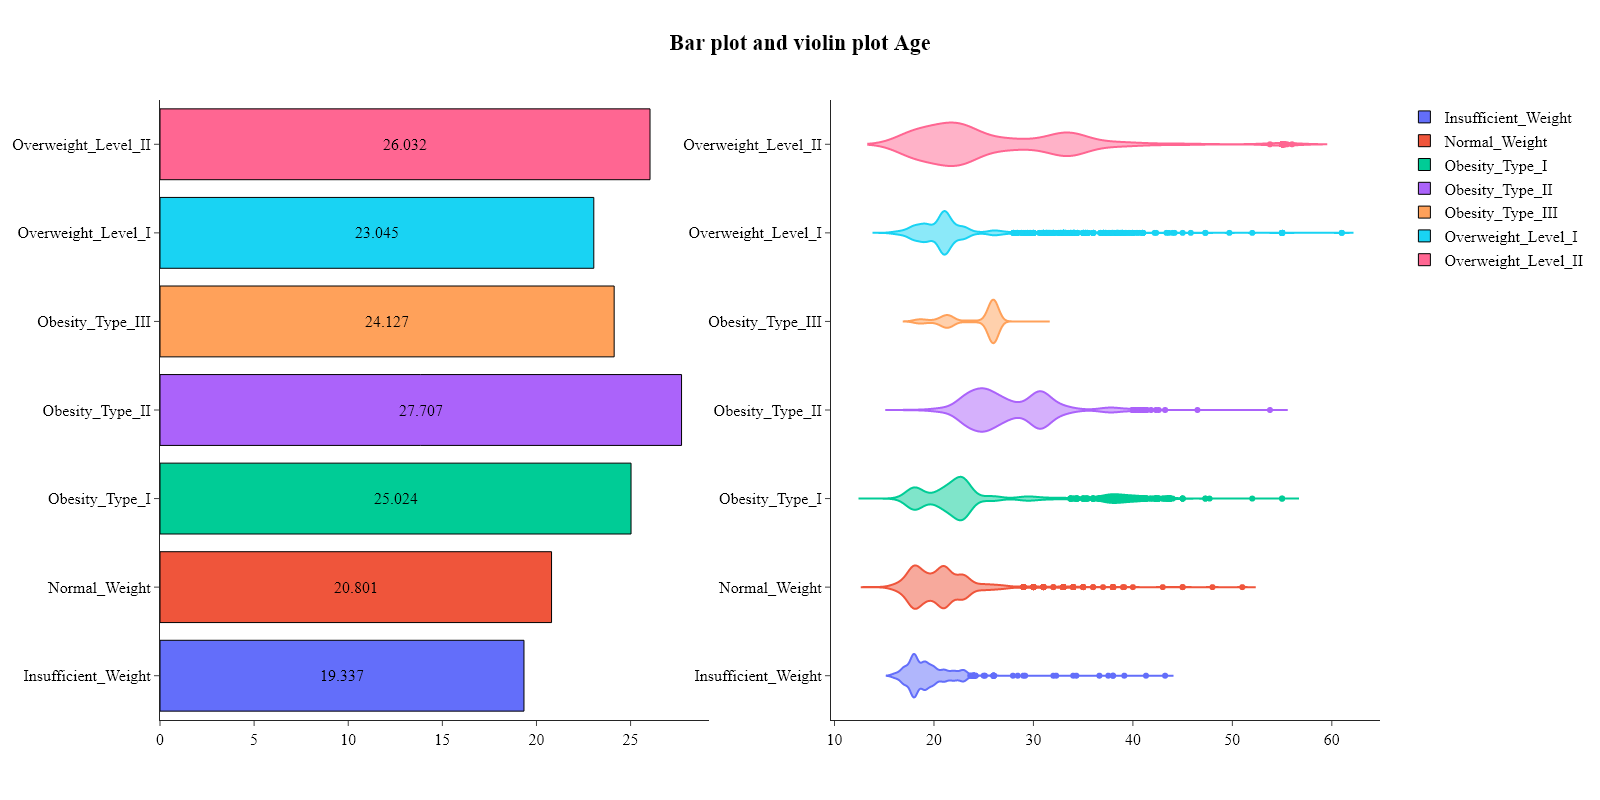

In [34]:
plots.barplot_and_violine_plot(data=train_data["Age"], hue=train_data[target_variable], name="Age")

#### Height

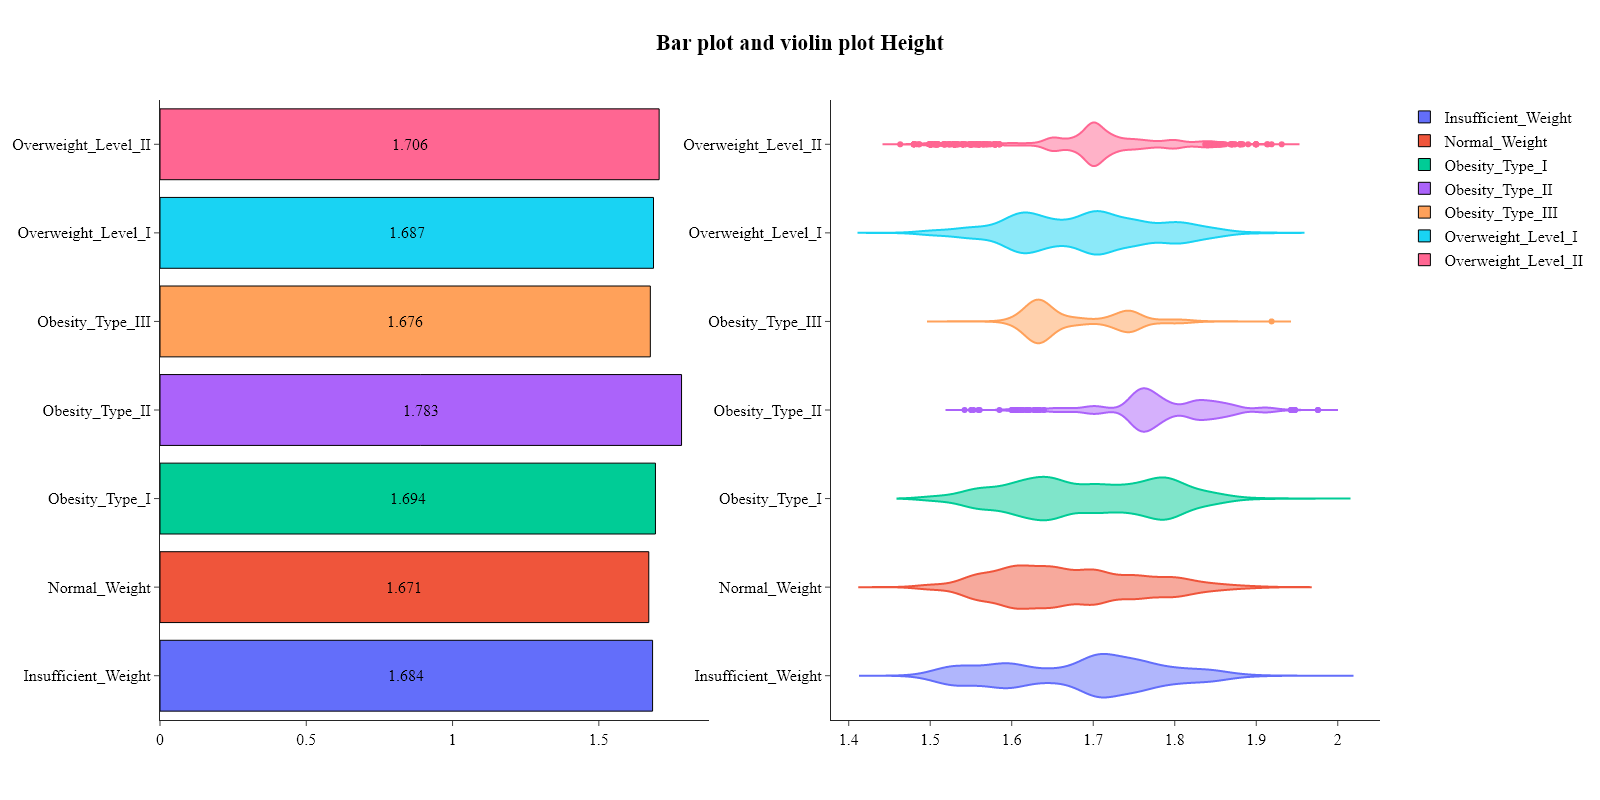

In [35]:
plots.barplot_and_violine_plot(data=train_data["Height"], hue=train_data[target_variable], name="Height")

#### Weight

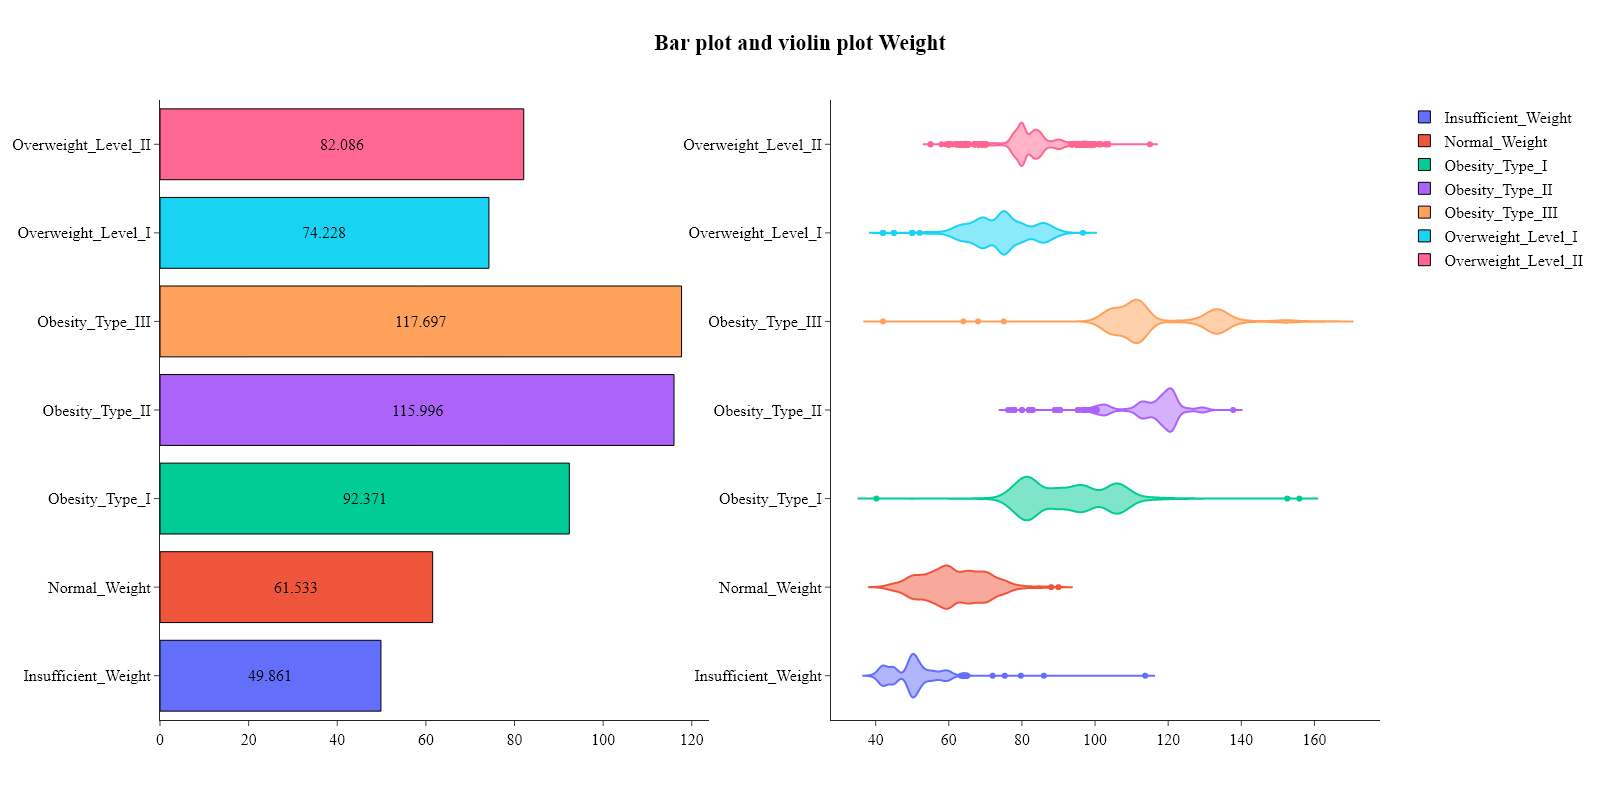

In [36]:
plots.barplot_and_violine_plot(data=train_data["Weight"], hue=train_data[target_variable], name="Weight")

#### FCVC

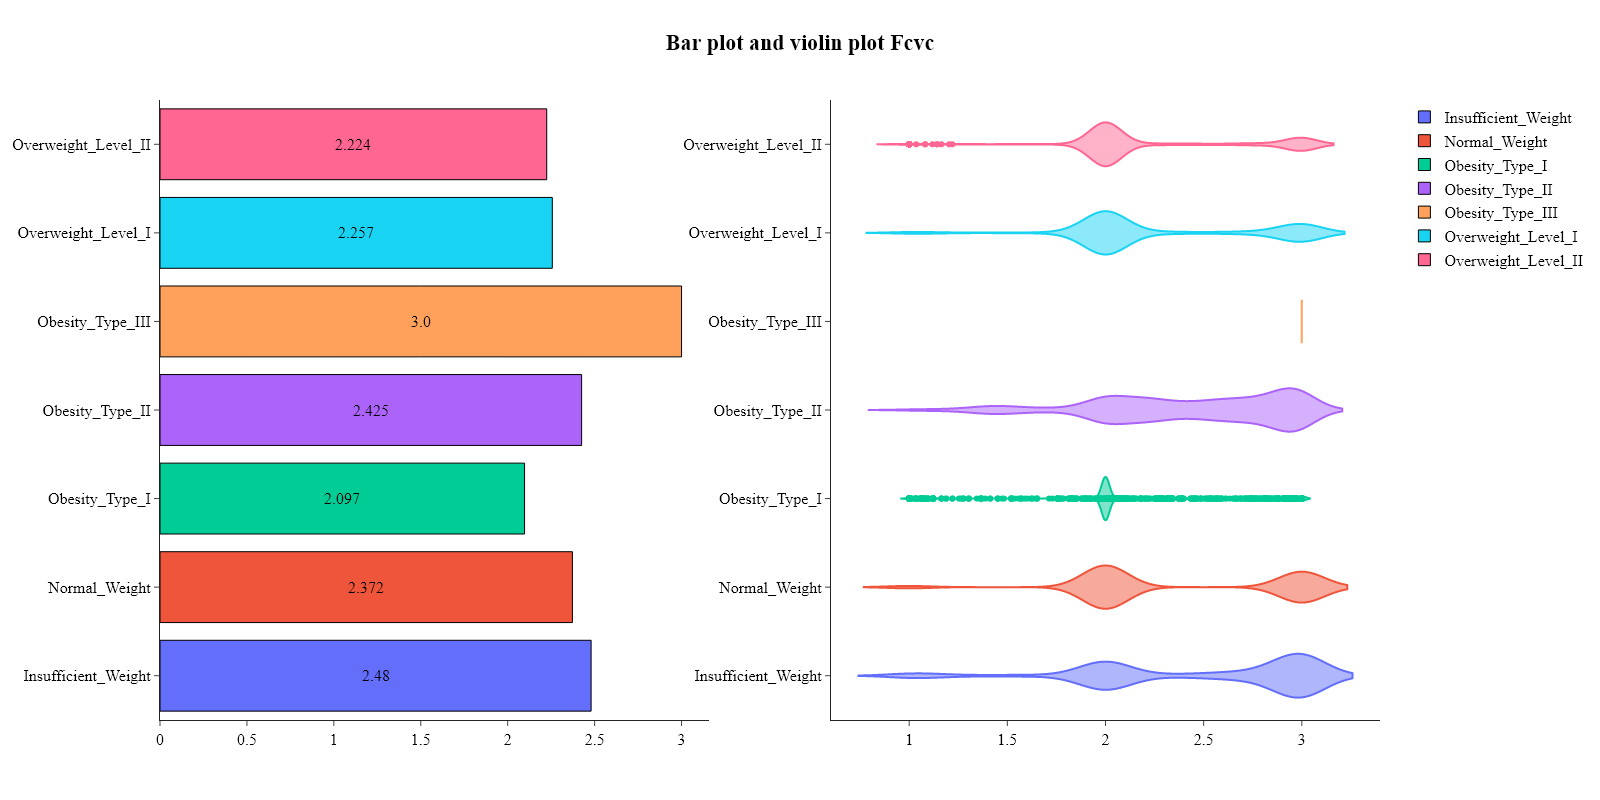

In [37]:
plots.barplot_and_violine_plot(data=train_data["FCVC"], hue=train_data[target_variable], name="FCVC")

#### NCP

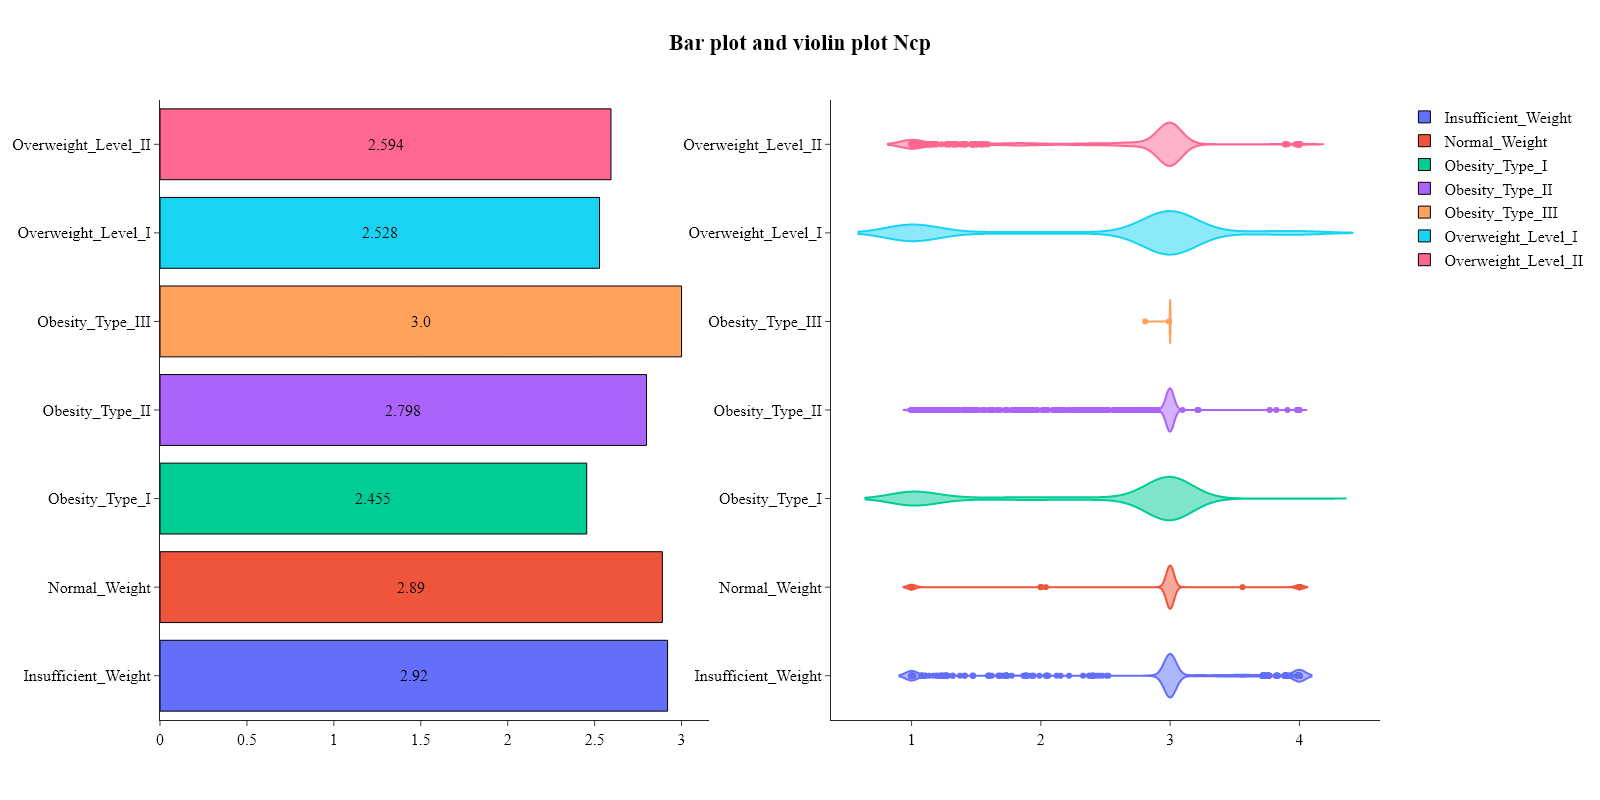

In [38]:
plots.barplot_and_violine_plot(data=train_data["NCP"], hue=train_data[target_variable], name="NCP")

#### CH2O

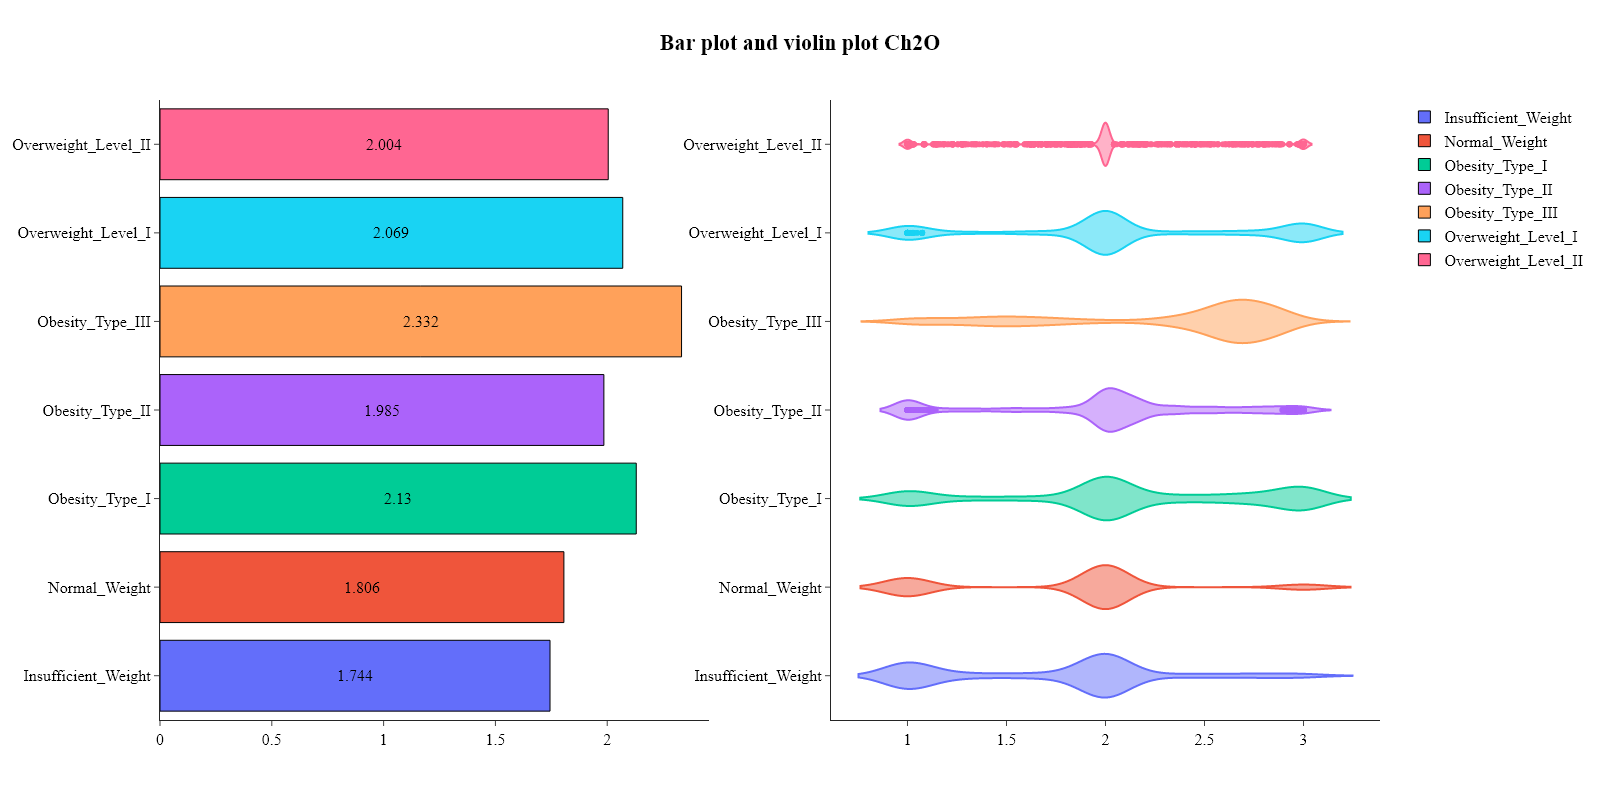

In [39]:
plots.barplot_and_violine_plot(data=train_data["CH2O"], hue=train_data[target_variable], name="CH2O")

#### FAF

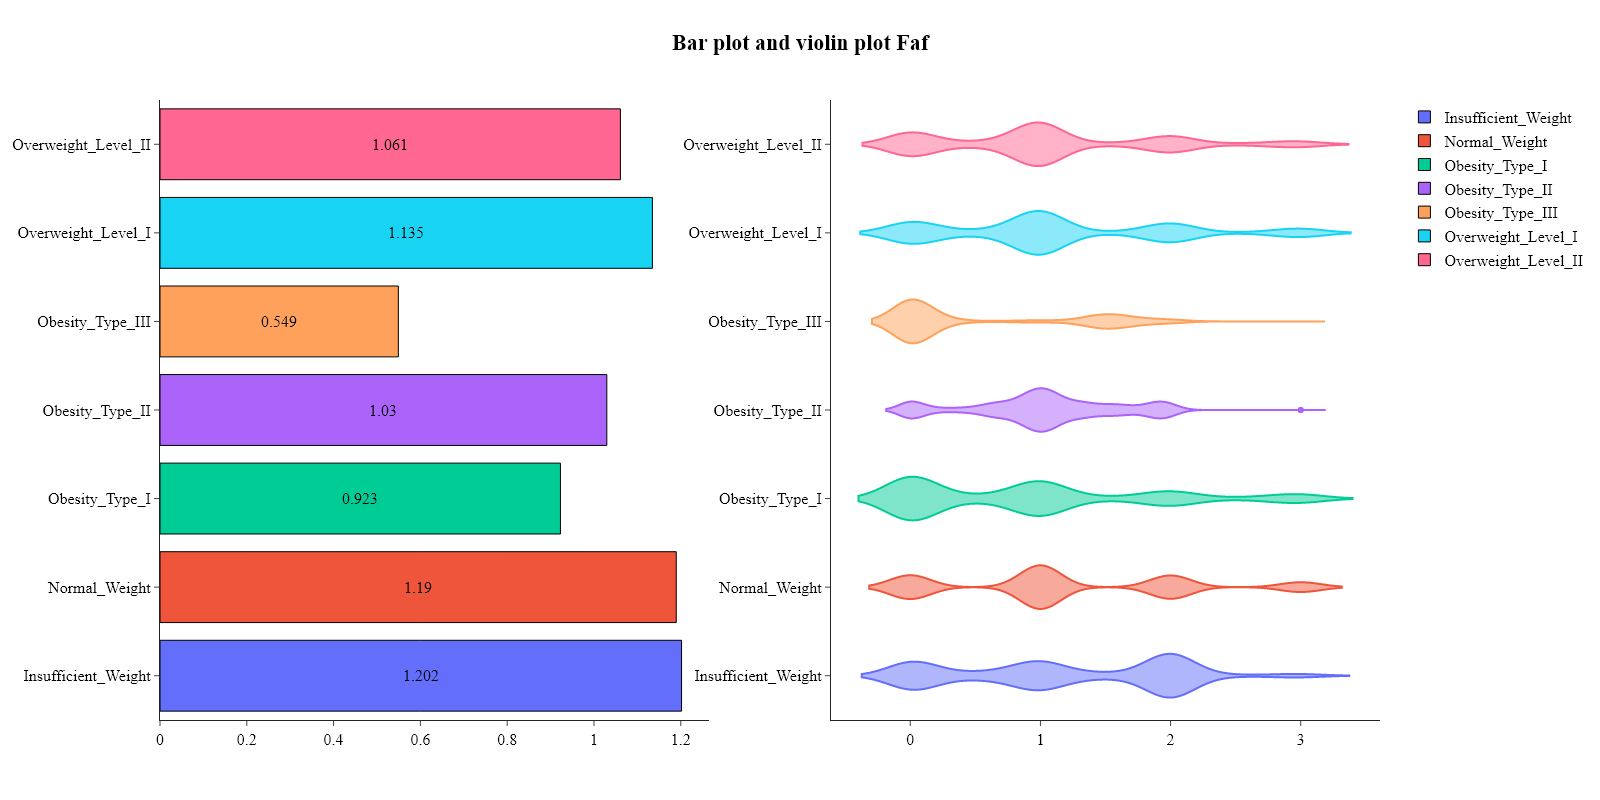

In [40]:
plots.barplot_and_violine_plot(data=train_data["FAF"], hue=train_data[target_variable], name="FAF")

#### TUE

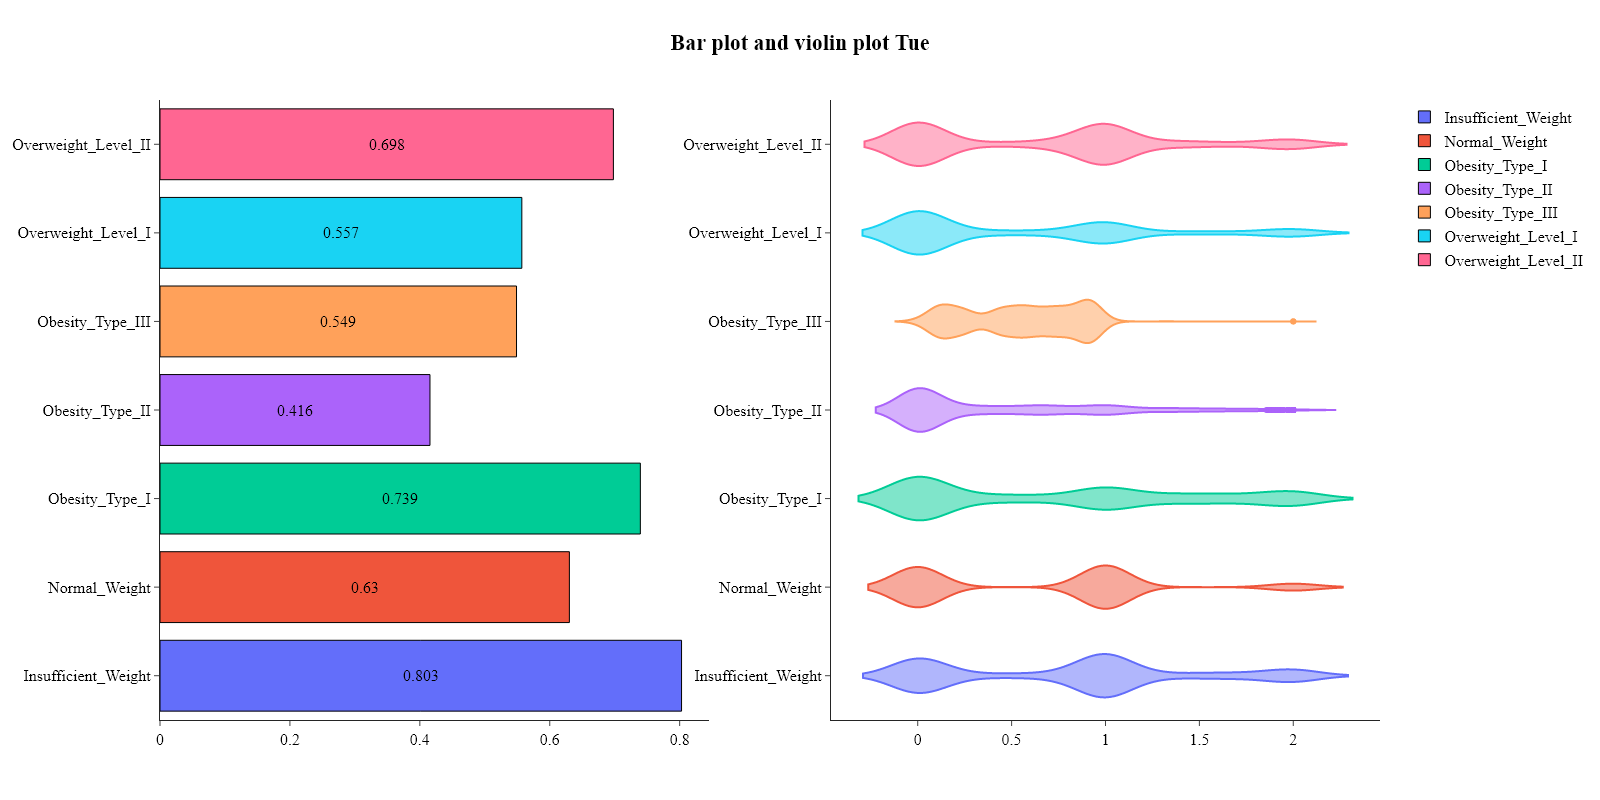

In [41]:
plots.barplot_and_violine_plot(data=train_data["TUE"], hue=train_data[target_variable], name="TUE")

## Correlation matrix

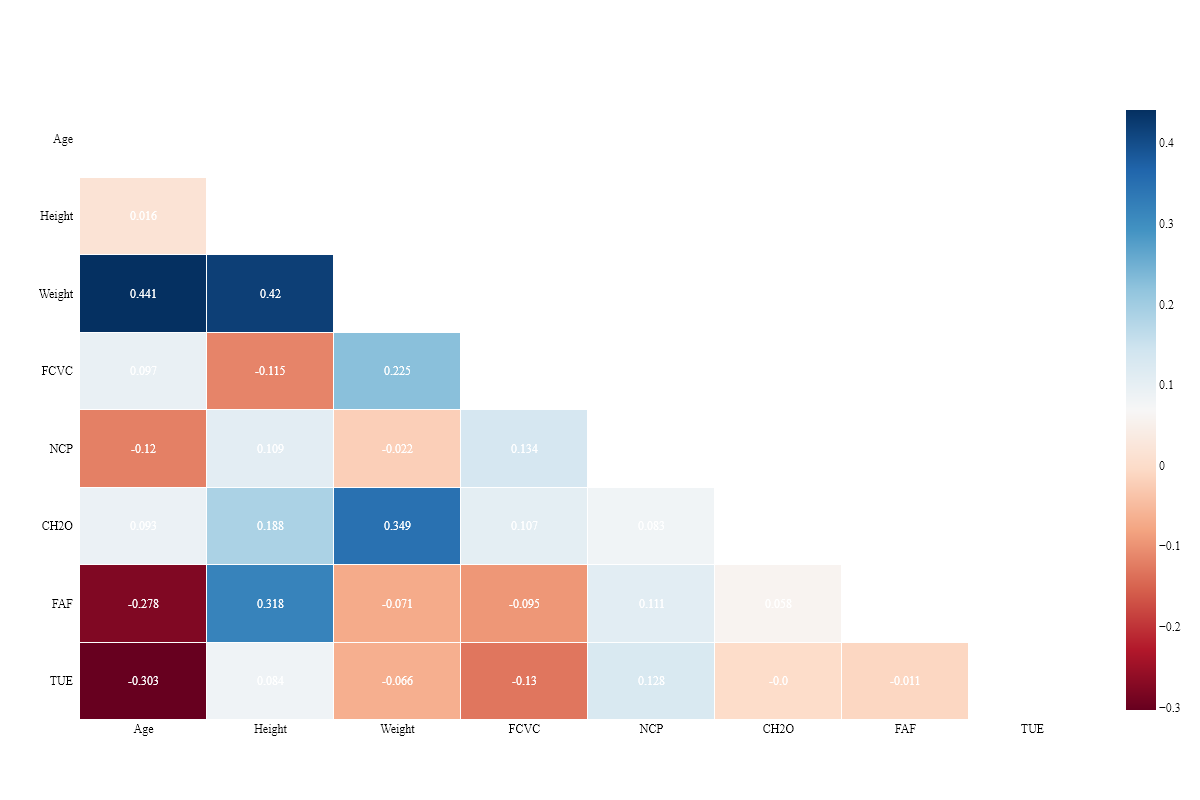

In [42]:
plots.correlation_plot(data=train_data.drop(target_variable, axis=1)[continous_features], features_names=train_data.drop(target_variable, axis=1)[continous_features].columns.tolist())

$\text{There is no strong correlation between features.}$

## Feature selection

https://www.kaggle.com/code/nicapotato/tree-split-feature-selection-lgbm-gpu-earlystop

In [43]:
train_data = pd.get_dummies(train_data, columns=categorical_features, drop_first=True)
test_data = pd.get_dummies(test_data, columns=categorical_features, drop_first=True)
X = train_data.drop(target_variable, axis=1)
y = train_data[target_variable]
label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y), name=target_variable)
categorical_features = train_data.select_dtypes(include=['bool']).columns.tolist()
for feature in categorical_features:
    X[feature] = X[feature].astype('category')

In [44]:
def cross_validation_feature_importance(X, y, categorical_features, metric, n_splits=5, random_state=17, num_estimators=1000, early_stopping_rounds=100):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    params = {'objective': 'multiclass', 'metric': metric, "num_classes": len(np.unique(y)), 'boosting_type': 'gbdt', 'random_state': random_state, "n_jobs": -1, 'verbose': -1}
    gain_importances, split_importances, shap_importances = [], [], []
    for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_train, X_valid = X.iloc[train_idx, :], X.iloc[valid_idx, :]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        lgb_train = lgb.Dataset(X_train, y_train, categorical_feature = categorical_features, free_raw_data=False)
        lgb_valid = lgb.Dataset(X_valid, y_valid, categorical_feature = categorical_features, free_raw_data=False)
        lgb_model = lgb.train(params, lgb_train, valid_sets=[lgb_train, lgb_valid], valid_names=['train','valid'], verbose_eval=0, num_boost_round = num_estimators, early_stopping_rounds=early_stopping_rounds)
        shap_values = shap.TreeExplainer(lgb_model).shap_values(X_valid)
        shap_importance = np.abs(np.concatenate(shap_values, axis=0)).mean(axis=0)
        normalized_shap_importance = shap_importance/np.sum(shap_importance)
        gain_importance = lgb_model.feature_importance(importance_type = 'gain')
        normalized_gain_importance = np.array(gain_importance)/np.sum(gain_importance)
        split_importance = lgb_model.feature_importance(importance_type = 'split')
        normalized_split_importance = np.array(split_importance)/np.sum(split_importance)
        gain_importances.append(normalized_gain_importance)
        split_importances.append(normalized_split_importance)
        shap_importances.append(normalized_shap_importance)
    results = {'feature': X.columns.tolist(), 'gain_std': np.std(gain_importances, axis=0), 'gain_mean': np.mean(gain_importances, axis=0), 'split_std': np.std(split_importances, axis=0), 'split_mean': np.mean(split_importances, axis=0), 'shap_std': np.std(shap_importances, axis=0), 'shap_mean': np.mean(shap_importances, axis=0)}
    results_df = pd.DataFrame(results)
    return results_df
metric = "auc_mu"
results = cross_validation_feature_importance(X, y, categorical_features, metric, n_splits=10, random_state=17, num_estimators=1000, early_stopping_rounds=100)

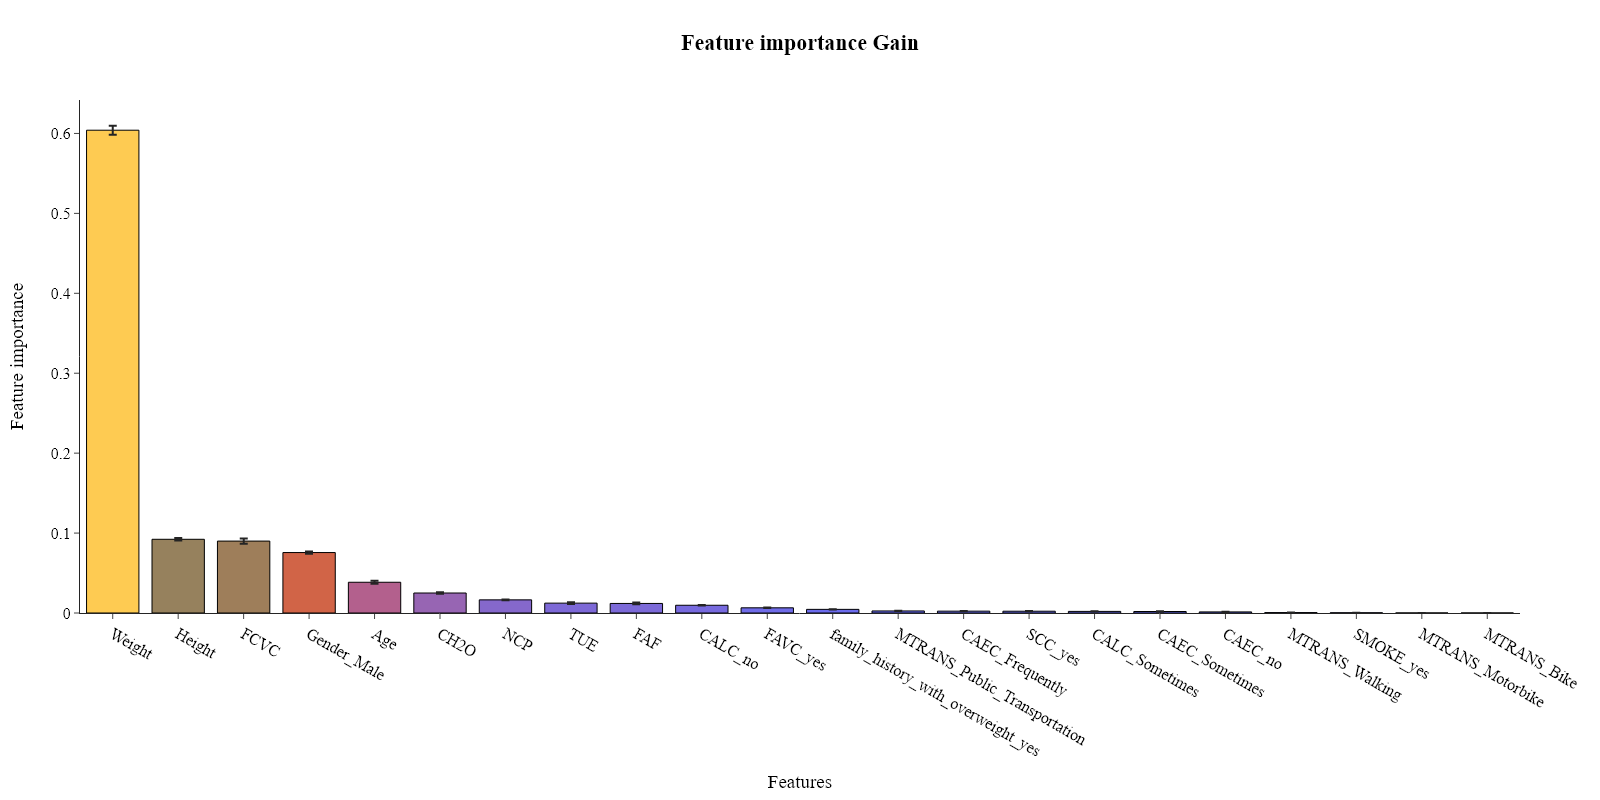

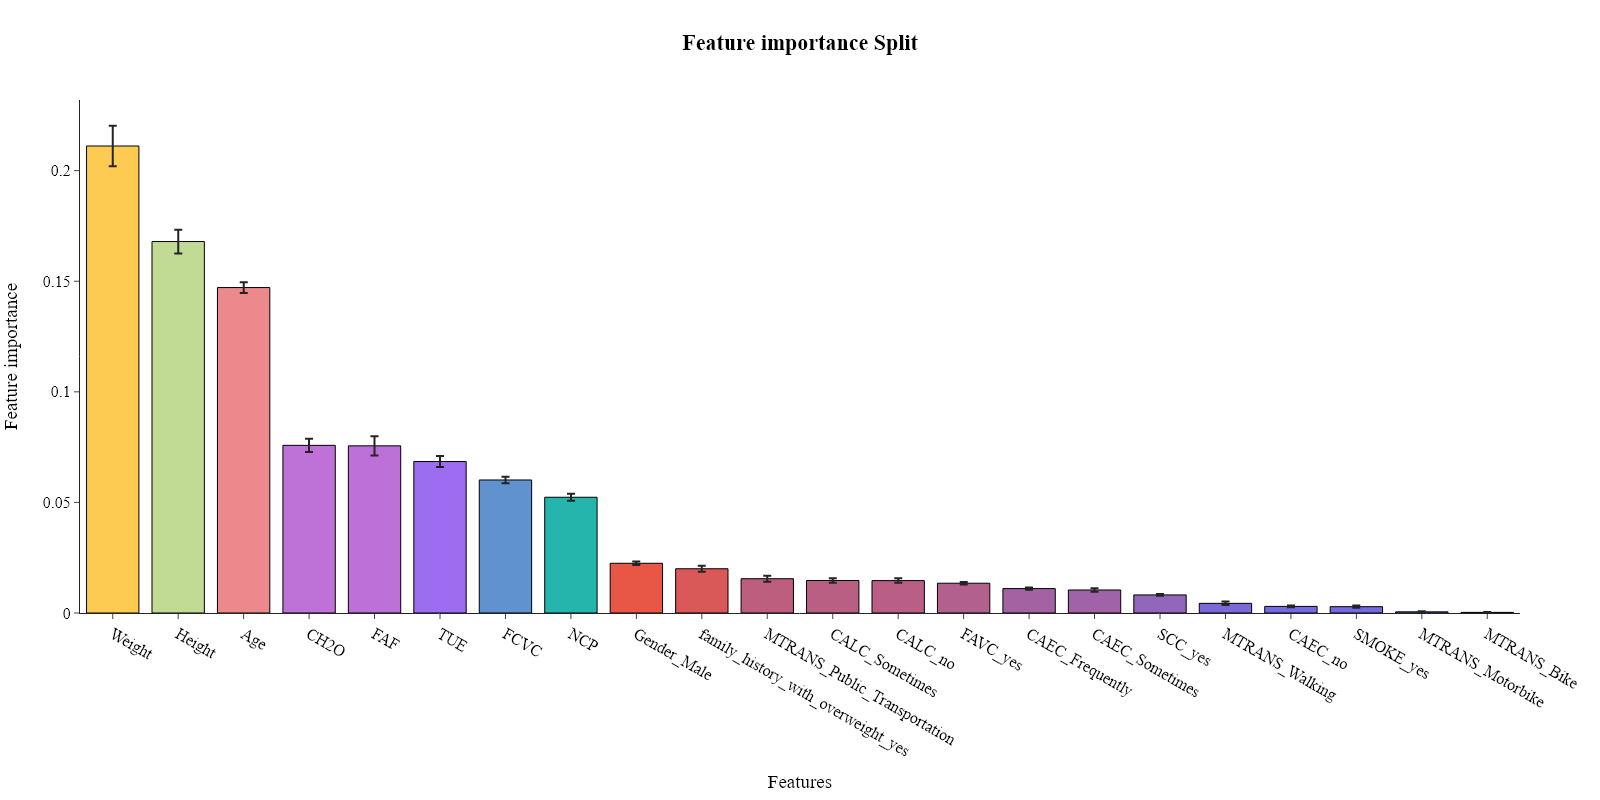

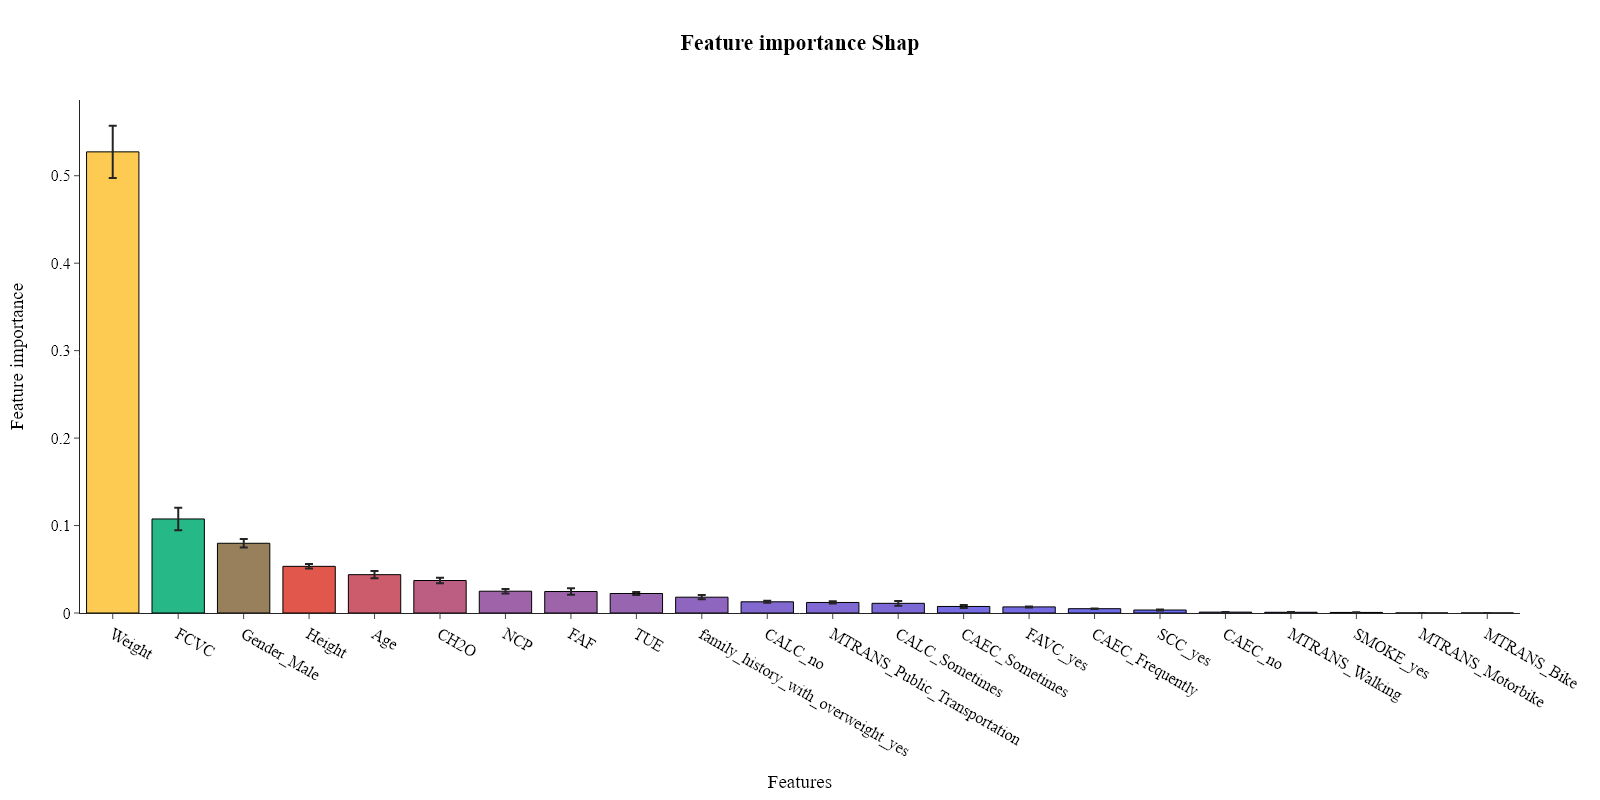

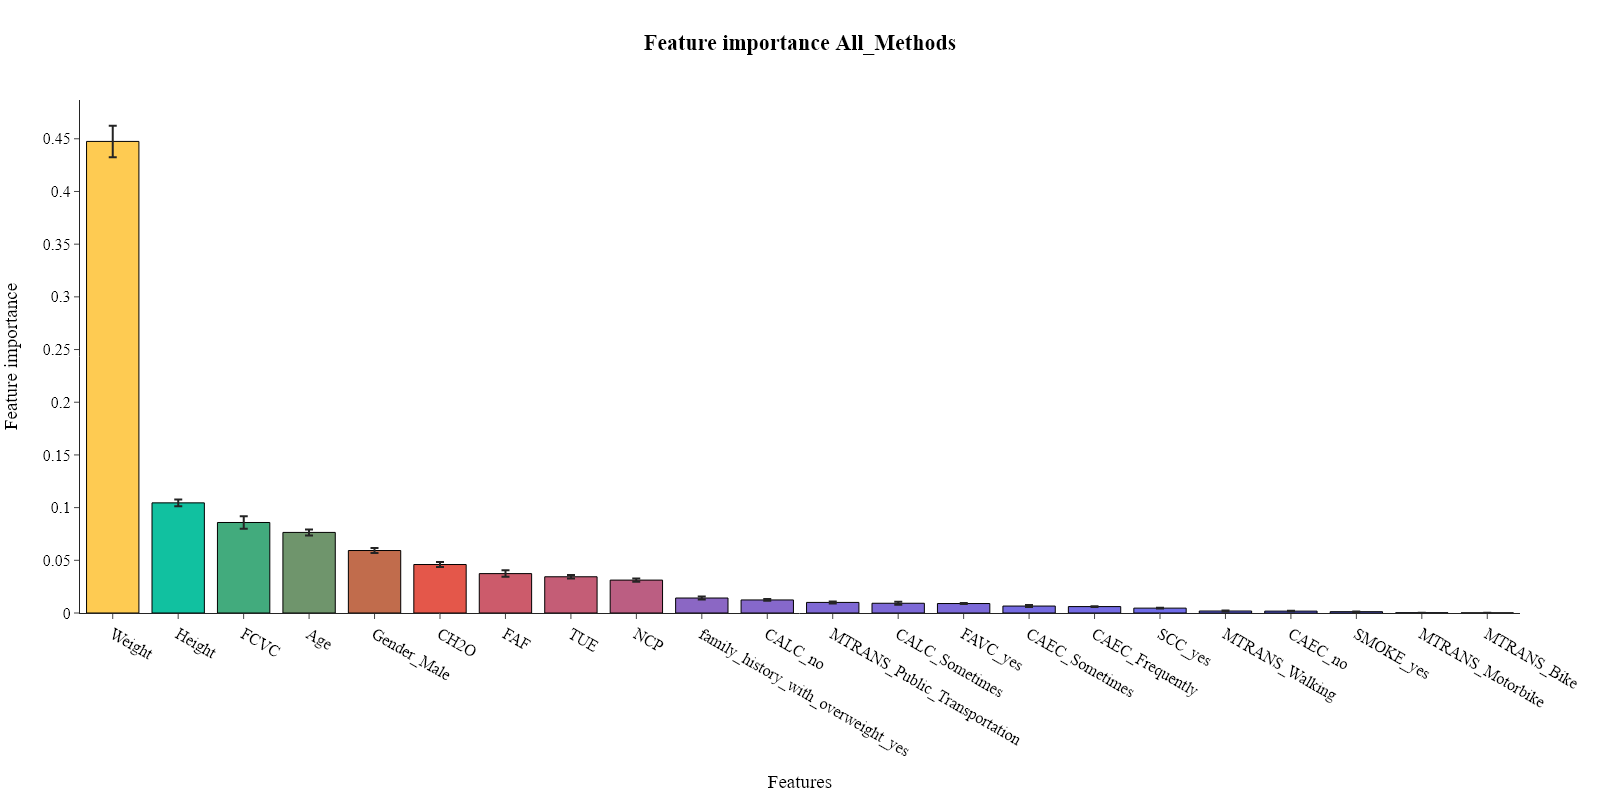

In [45]:
results["all_methods_mean"] = results[["gain_mean", "split_mean", "shap_mean"]].mean(axis=1)
results["all_methods_std"] = results[["gain_std", "split_std", "shap_std"]].mean(axis=1)
for importance_type in ["gain", "split", "shap", "all_methods"]:
    plots.plot_feature_importances(results, importance_type=importance_type)

$\text{Feature importances for all methods are very similar.}$<p>
$\text{Weight is the most important feature based on all methods.}$

In [46]:
results["ranking"] = results["all_methods_mean"].rank(ascending=False).astype(int)
results

,feature,gain_std,gain_mean,split_std,split_mean,shap_std,shap_mean,all_methods_mean,all_methods_std,ranking
0,Age,0.001920,0.038463,0.002429,0.147141,0.004177,0.043825,0.076477,0.002842,4
1,Height,0.001651,0.092222,0.005351,0.167948,0.002548,0.053368,0.104513,0.003184,2
2,Weight,0.005709,0.604050,0.009207,0.211140,0.029977,0.527289,0.447493,0.014964,1
3,FCVC,0.003251,0.089981,0.001509,0.060143,0.012957,0.107528,0.085884,0.005906,3
4,NCP,0.000553,0.016423,0.001590,0.052330,0.002529,0.024917,0.031223,0.001557,9
5,CH2O,0.000896,0.025025,0.002988,0.075801,0.003221,0.037150,0.045992,0.002368,6
6,FAF,0.001101,0.011964,0.004367,0.075574,0.003784,0.024561,0.037366,0.003084,7
7,TUE,0.000967,0.012344,0.002455,0.068486,0.001792,0.022286,0.034372,0.001738,8
8,Gender_Male,0.001445,0.075636,0.000762,0.022478,0.004789,0.079738,0.059284,0.002332,5
9,family_history_with_overweight_yes,0.000285,0.004550,0.001363,0.020004,0.002396,0.018064,0.014206,0.001348,10


In [47]:
class Gradient_Feature_selection():
    def __init__(self, random_state):
        self.random_state = random_state
        np.random.seed(self.random_state)
        random.seed(self.random_state)

    def check_data(self, X, y):
        if isinstance(X, pd.DataFrame) and isinstance(y, pd.Series):
            return X, y
        else:
            raise ValueError("X and y should be pandas dataframe and series respectively")
    
    def check_metric(self, metric):
        metrics = {"accuracy": [lambda y, y_pred: accuracy_score(y, y_pred), "preds"],
                    "roc_auc": [lambda y, y_pred: roc_auc_score(y, y_pred), "probs"],
                    "f1": [lambda y, y_pred: f1_score(y, y_pred, average="weighted"), "preds"],
                    "auc_mu": [lambda y, y_pred: roc_auc_score(y, y_pred, multi_class='ovr'), "probs"],
                    "mse": [lambda y, y_pred: mean_squared_error(y, y_pred), "preds"],
                    "rmse": [lambda y, y_pred: mean_squared_error(y, y_pred)**0.5, "preds"],
                    "mae": [lambda y, y_pred: mean_absolute_error(y, y_pred), "preds"]}
        if metric in metrics:
            return metrics[metric][0], metrics[metric][1]
        else:
            raise ValueError("Invalid metric. Please choose from the following: accuracy, roc_auc, f1, auc_mu, mse, rmse, mae")
    
    def fit(self, algorithm, X, y, metric, n_splits=5, learning_rate=1e-2, n_iter=100, objective="maximize"):
        X, y = self.check_data(X, y)
        self.eval_metric, self.metric_type = self.check_metric(metric)
        self.algorithm = algorithm
        self.n_splits = n_splits
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.objective = objective
        self.feature_importance_, self.selected_features_, self.best_score_ = self.perform_feature_selection(X, y)
        return self
    
    def fit_transform(self, algorithm, X, y, metric, n_splits=5, learning_rate=1e-2, n_iter=100, objective="maximize"):
        self.fit(algorithm, X, y, metric, n_splits, learning_rate, n_iter, objective)
        return X[self.selected_features_]
    
    def transform(self, X):
        return X[self.selected_features_]

    def perform_feature_selection(self, X, y):
        self.base_score = self.cross_val_score(X, y)
        best_score = self.base_score
        best_subset = X.columns.tolist()
        used_subset = set()
        feature_weights = {feature: 1/X.shape[1] for feature in X.columns}
        number_of_possible_subsets = 2**X.shape[1]
        for iter in range(self.n_iter):
            if(iter==number_of_possible_subsets):
                break
            while True:
                feature_subset = np.random.choice(X.columns, size=np.random.randint(1, X.shape[1]), replace=False, p=[feature_weights[feature] for feature in X.columns])
                if tuple(feature_subset) not in used_subset:
                    break
            X_subset = X[feature_subset]
            subset_score = self.cross_val_score(X_subset, y)
            loss = self.base_score - subset_score
            if(self.objective=="maximize"):
                if(subset_score > best_score):
                    best_score = subset_score
                    best_subset = feature_subset.tolist()
                feature_weights.update({feature: np.min([np.max([feature_weights[feature]-self.learning_rate*loss, 0]), 1]) if feature in feature_subset else feature_weights[feature] for feature in X.columns})
            else:
                if(subset_score < best_score):
                    best_score = subset_score
                    best_subset = feature_subset.tolist()
                feature_weights.update({feature: np.min([np.max([feature_weights[feature]+self.learning_rate*loss, 0]), 1]) if feature in feature_subset else feature_weights[feature] for feature in X.columns})
            feature_weights = {feature: feature_weights[feature]/sum(feature_weights.values()) for feature in feature_weights}
            if(iter%50==0):
                print(f"Iteration: {iter}, Best score: {best_score}; best subset: {best_subset}")
            used_subset.add(tuple(best_subset))
        return feature_weights, best_subset, best_score
    
    def cross_val_score(self, X, y):
        cv = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        cross_validation_scores = []
        for iter, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]
            self.algorithm.fit(X_train, y_train)
            if(self.metric_type == "preds"):
                y_pred = self.algorithm.predict(X_valid)
            else:
                y_pred = self.algorithm.predict_proba(X_valid)[:,-1]
            cross_validation_scores.append(self.eval_metric(y_valid, y_pred))
        return np.mean(cross_validation_scores)

In [48]:
gradient_selector = Gradient_Feature_selection(random_state=17)
lgbm = LGBMClassifier(n_estimators=100, random_state=17, objective="multiclass", metric="auc_mu", num_classes=len(np.unique(y)), boosting_type="gbdt", n_jobs=-1, verbose=-1)
gradient_selector.fit(lgbm, X, y, "f1", n_splits=5, learning_rate=1e-2, n_iter=500, objective="maximize")

{'Age': 0.045389074229682205, 'Height': 0.045629135387514126, 'Weight': 0.045389074229682205, 'FCVC': 0.045389074229682205, 'NCP': 0.045389074229682205, 'CH2O': 0.045389074229682205, 'FAF': 0.045389074229682205, 'TUE': 0.045389074229682205, 'Gender_Male': 0.045389074229682205, 'family_history_with_overweight_yes': 0.045389074229682205, 'FAVC_yes': 0.045389074229682205, 'CAEC_Frequently': 0.045629135387514126, 'CAEC_Sometimes': 0.045389074229682205, 'CAEC_no': 0.045389074229682205, 'SMOKE_yes': 0.045629135387514126, 'SCC_yes': 0.045629135387514126, 'CALC_Sometimes': 0.045389074229682205, 'CALC_no': 0.045389074229682205, 'MTRANS_Bike': 0.045389074229682205, 'MTRANS_Motorbike': 0.045389074229682205, 'MTRANS_Public_Transportation': 0.045629135387514126, 'MTRANS_Walking': 0.045629135387514126}
Iteration: 0, Best score: 0.9020721491721714
{'Age': 0.043962068384746554, 'Height': 0.04629718025404592, 'Weight': 0.04605360442027765, 'FCVC': 0.043962068384746554, 'NCP': 0.04605360442027765, 'CH2O

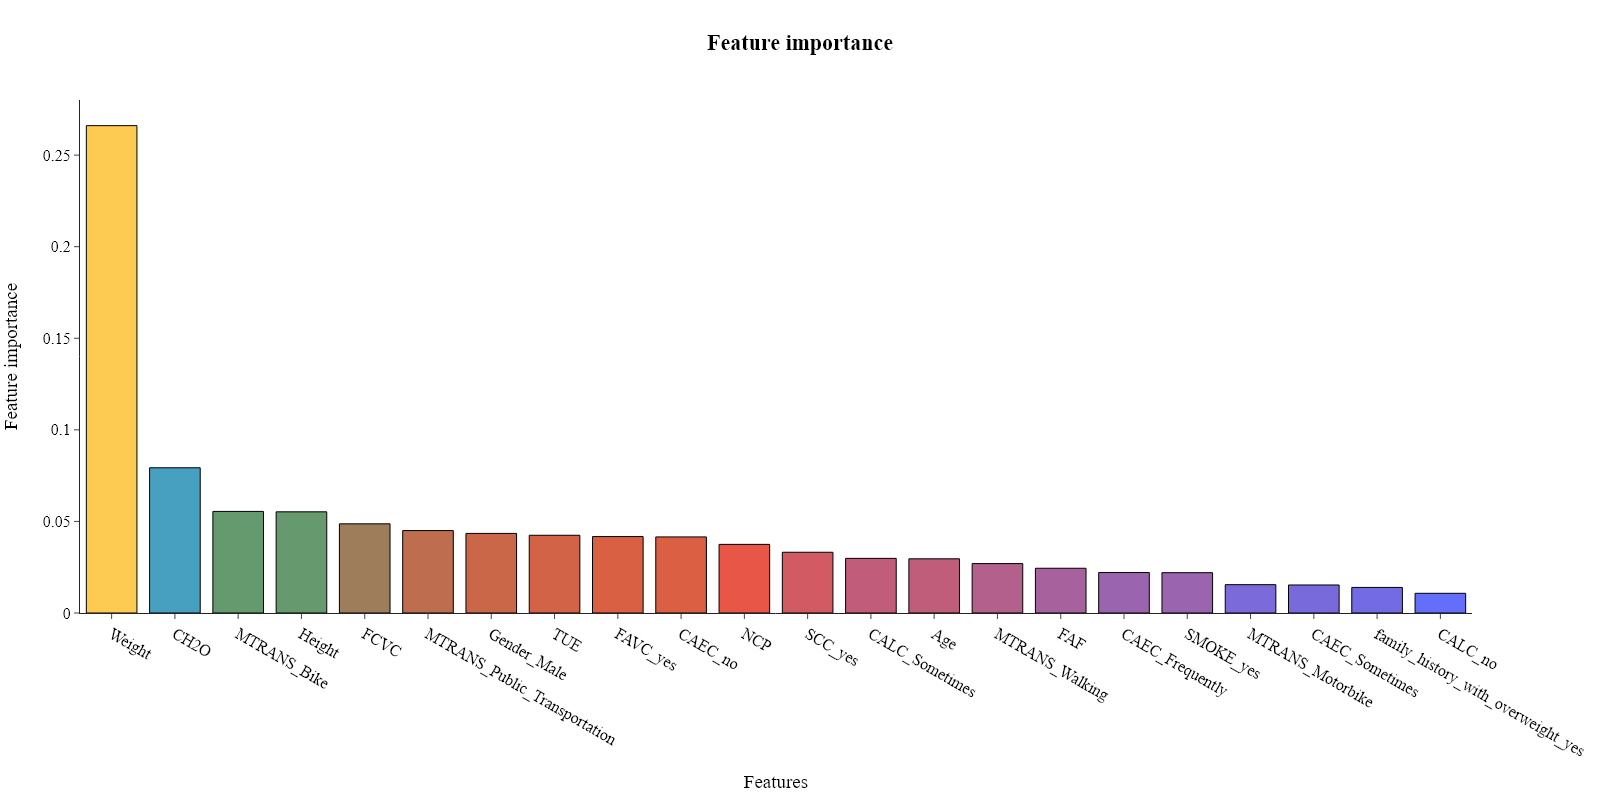

In [49]:
results = pd.DataFrame(gradient_selector.feature_importance_, index=["gradient_importance"]).T
plots.simple_feature_importance(results, importance_type="gradient_importance")

In [50]:
print("Selected features: {}".format(gradient_selector.selected_features_))

Selected features: ['Age', 'family_history_with_overweight_yes', 'CH2O', 'Weight', 'CALC_Sometimes', 'CAEC_Frequently', 'SCC_yes', 'MTRANS_Public_Transportation', 'Height', 'NCP', 'FCVC', 'CALC_no', 'FAVC_yes', 'CAEC_no', 'FAF', 'MTRANS_Motorbike', 'SMOKE_yes', 'TUE', 'CAEC_Sometimes', 'Gender_Male']


In [ ]:
print("Base score after training with all features: {}".format(gradient_selector.base_score))
print("Best score after training with selected features: {}".format(gradient_selector.best_score_))

Base score after training with all features: 0.9891975494440267
Best score after training with selected features: 0.9891975494440267


# Modeling

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(train_data.drop(target_variable, axis=1), train_data[target_variable], test_size=0.2, random_state=17)

In [ ]:
def objective(trial, X_train, y_train, X_valid, y_valid):
    param = {
        "objective": "multiclass",
        "metric": "multi_logloss",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": 17,
        "num_class": 7,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "n_estimators": trial.suggest_int("n_estimators", 400, 600),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.005, 0.015),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.02, 0.06),
        "max_depth": trial.suggest_int("max_depth", 6, 14),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.9),
        "subsample": trial.suggest_float("subsample", 0.8, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50)
    }
    lgbm_classifier = LGBMClassifier(**param)
    lgbm_classifier.fit(X_train, y_train)
    return lgbm_classifier.score(X_valid, y_valid)
sampler = optuna.samplers.TPESampler(seed=17)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(lambda trial: objective(trial, X_train, y_train, X_valid, y_valid), n_trials=100)
best_params = study.best_params
print(best_params)

[I 2024-02-06 01:19:41,503] A new study created in memory with name: no-name-663a051a-fdc0-40cb-a923-58f3f0d1e27a


[LightGBM] [Warning] lambda_l1 is set=0.006915207869474948, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.006915207869474948
[LightGBM] [Warning] lambda_l2 is set=0.022716014327651655, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.022716014327651655


[I 2024-02-06 01:19:49,895] Trial 0 finished with value: 0.9173892100192679 and parameters: {'learning_rate': 0.02178660010748439, 'n_estimators': 506, 'lambda_l1': 0.006915207869474948, 'lambda_l2': 0.022716014327651655, 'max_depth': 13, 'colsample_bytree': 0.6938001130655134, 'subsample': 0.9275041792087272, 'min_child_samples': 33}. Best is trial 0 with value: 0.9173892100192679.


[LightGBM] [Warning] lambda_l1 is set=0.014456831868184073, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.014456831868184073
[LightGBM] [Warning] lambda_l2 is set=0.022401787212615414, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.022401787212615414


[I 2024-02-06 01:19:54,255] Trial 1 finished with value: 0.910645472061657 and parameters: {'learning_rate': 0.01156251664755466, 'n_estimators': 471, 'lambda_l1': 0.014456831868184073, 'lambda_l2': 0.022401787212615414, 'max_depth': 13, 'colsample_bytree': 0.8263743156888181, 'subsample': 0.8102387331240908, 'min_child_samples': 36}. Best is trial 0 with value: 0.9173892100192679.


...

[LightGBM] [Warning] lambda_l1 is set=0.005408445425143732, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.005408445425143732
[LightGBM] [Warning] lambda_l2 is set=0.029987768928741894, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.029987768928741894


[I 2024-02-06 01:26:18,417] Trial 98 finished with value: 0.9161849710982659 and parameters: {'learning_rate': 0.02300194433897649, 'n_estimators': 541, 'lambda_l1': 0.005408445425143732, 'lambda_l2': 0.029987768928741894, 'max_depth': 12, 'colsample_bytree': 0.5108990268071896, 'subsample': 0.9066822575975894, 'min_child_samples': 35}. Best is trial 0 with value: 0.9173892100192679.


[LightGBM] [Warning] lambda_l1 is set=0.0062249819649027515, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0062249819649027515
[LightGBM] [Warning] lambda_l2 is set=0.024628015336843542, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.024628015336843542


[I 2024-02-06 01:26:22,624] Trial 99 finished with value: 0.9159441233140655 and parameters: {'learning_rate': 0.02024785017011261, 'n_estimators': 478, 'lambda_l1': 0.0062249819649027515, 'lambda_l2': 0.024628015336843542, 'max_depth': 12, 'colsample_bytree': 0.5427037990636988, 'subsample': 0.9412724341103332, 'min_child_samples': 40}. Best is trial 0 with value: 0.9173892100192679.


{'learning_rate': 0.02178660010748439, 'n_estimators': 506, 'lambda_l1': 0.006915207869474948, 'lambda_l2': 0.022716014327651655, 'max_depth': 13, 'colsample_bytree': 0.6938001130655134, 'subsample': 0.9275041792087272, 'min_child_samples': 33}


# Evaluation

In [ ]:
final_model = LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)
y_valid_pred = final_model.predict(X_valid)

[LightGBM] [Warning] lambda_l1 is set=0.006915207869474948, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.006915207869474948
[LightGBM] [Warning] lambda_l2 is set=0.022716014327651655, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.022716014327651655


In [ ]:
print(classification_report(y_valid, y_valid_pred))

                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.94      0.95       541
      Normal_Weight       0.89      0.90      0.89       609
     Obesity_Type_I       0.91      0.86      0.89       559
    Obesity_Type_II       0.98      0.98      0.98       642
   Obesity_Type_III       0.99      1.00      1.00       849
 Overweight_Level_I       0.79      0.81      0.80       448
Overweight_Level_II       0.81      0.83      0.82       504

           accuracy                           0.91      4152
          macro avg       0.90      0.90      0.90      4152
       weighted avg       0.91      0.91      0.91      4152



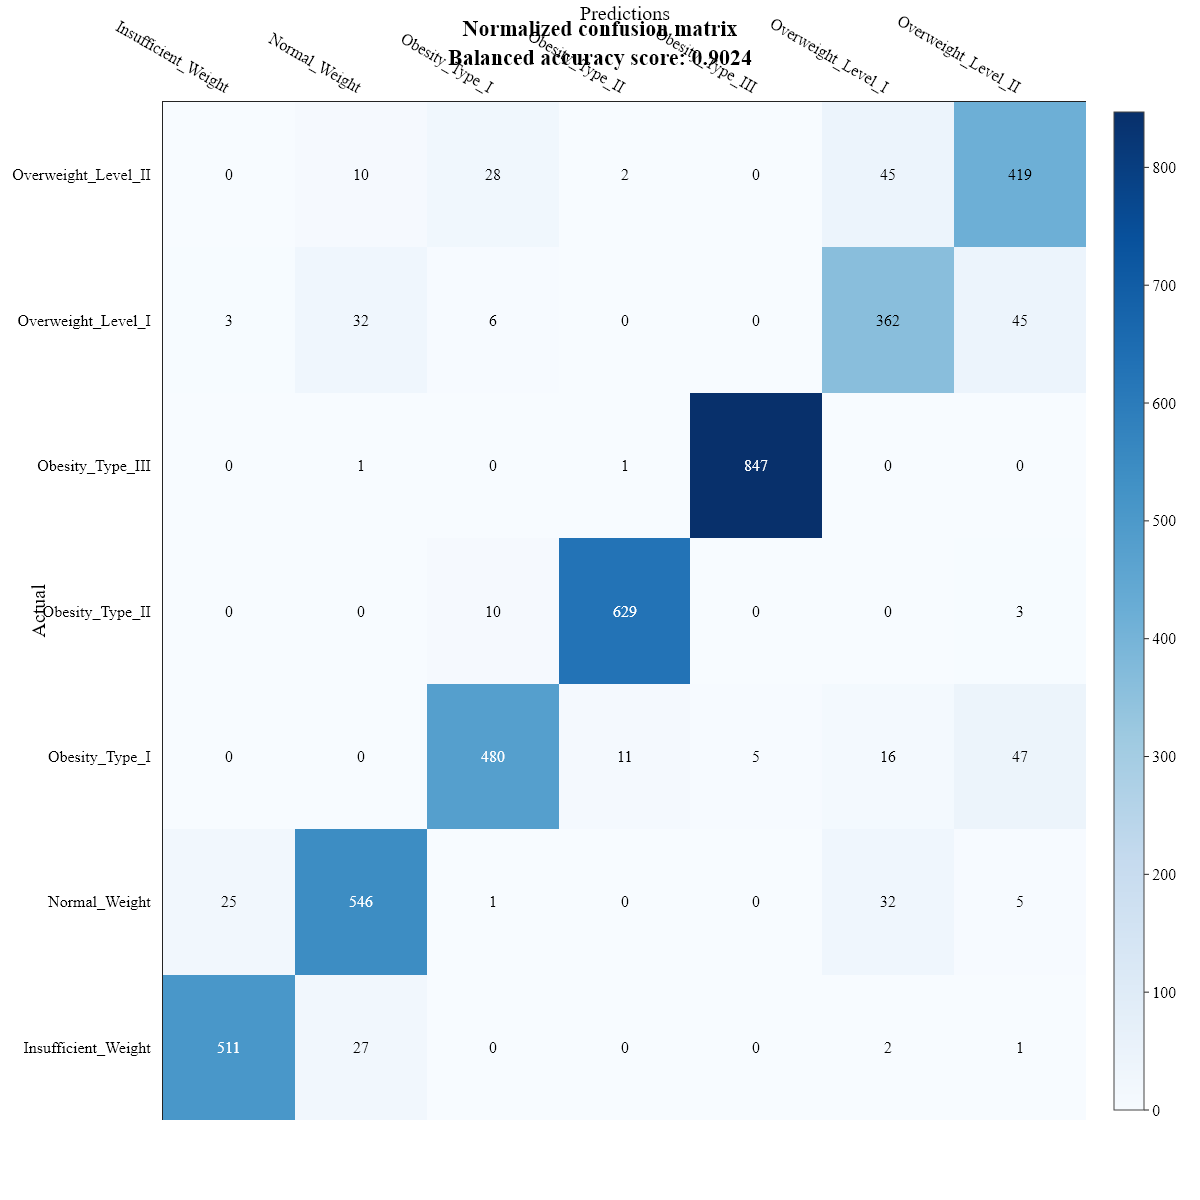

In [ ]:
plots.multilabel_conf_matrix(y_valid, y_valid_pred, labels=np.unique(y_valid), normalize=False)

## Feature importance

[LightGBM] [Warning] lambda_l1 is set=0.006915207869474948, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.006915207869474948
[LightGBM] [Warning] lambda_l2 is set=0.022716014327651655, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.022716014327651655


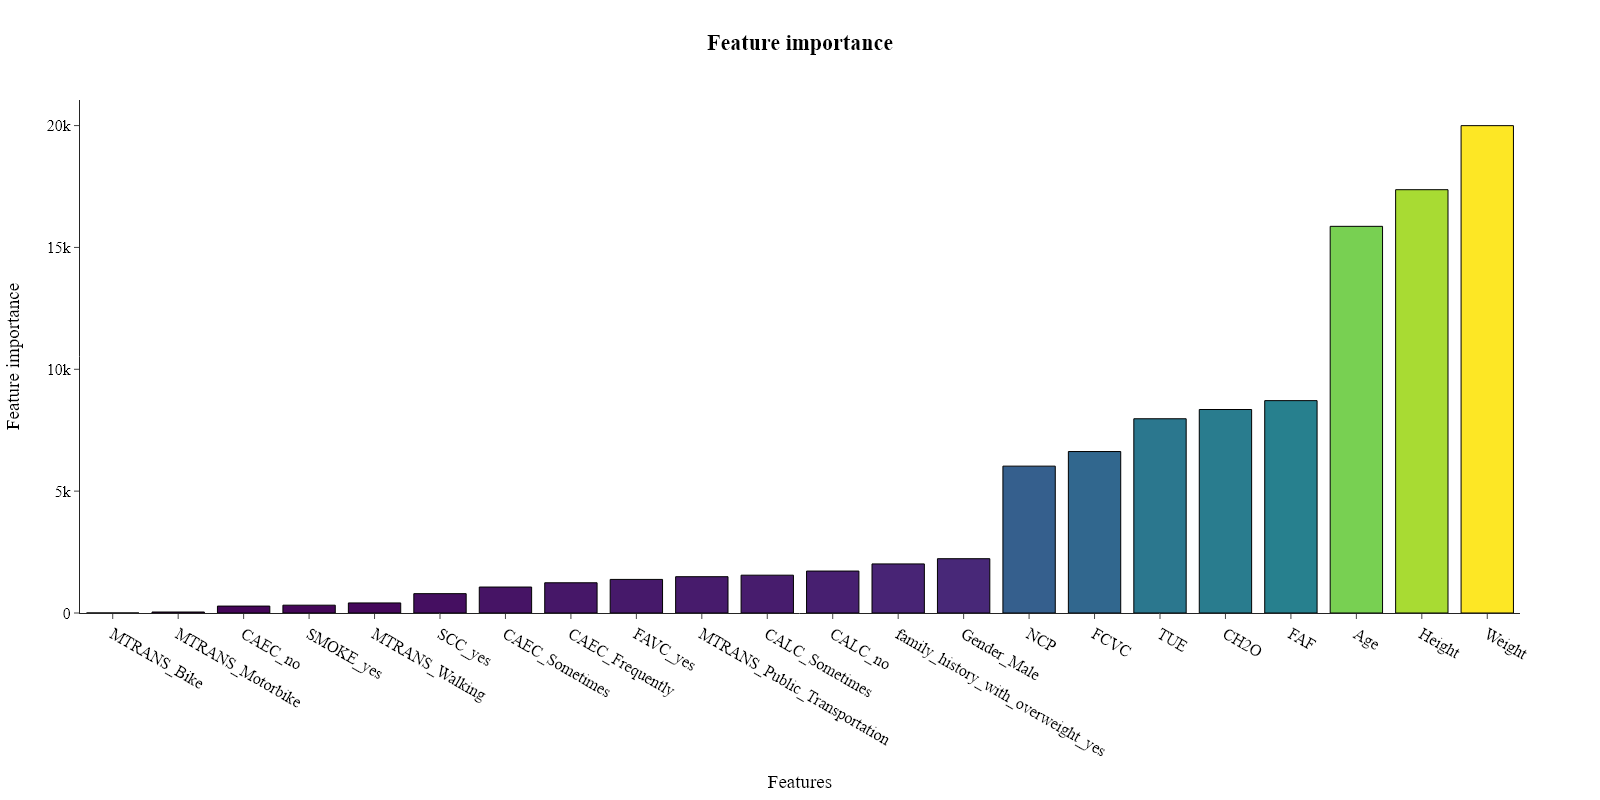

In [ ]:
final_model = LGBMClassifier(**best_params)
final_model.fit(train_data.drop(target_variable, axis=1), train_data[target_variable])
plots.plot_feature_importances(final_model.feature_importances_, column_names=X_train.columns.tolist())

In [ ]:
submission = pd.read_csv("input/sample_submission.csv")
submission[target_variable] = final_model.predict(test_data)
#submission.to_csv("submission.csv", index=False)
submission.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


Tutaj jest jeszcze jakiś tuning dla XGB (i z walidacją krzyżową w optunie): https://www.kaggle.com/code/lucamassaron/easy-peasy-eda-xgboost-is-all-you-need